In [2]:
import stanza
import spacy
from supar import Parser
from conllu import parse_incr
from collections import defaultdict
from pathlib import Path
from tqdm import tqdm
import re
from collections import defaultdict, Counter

/Users/frapadovani/Desktop/CHILDES-Parser/supar_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def load_conllu_gold(path):
    """
    Load gold annotations from a CONLLU file.
    Returns list of sentences, each as a list of dicts:
    {
        'form': str, 
        'upos': str, 
        'xpos': str, 
        'head': int, 
        'deprel': str
    }
    """
    sentences = []
    with open(path, "r", encoding="utf-8") as f:
        for tokenlist in parse_incr(f):
            tokens = []
            for token in tokenlist:
                if isinstance(token["id"], tuple):  # skip multi-word tokens like "2-3"
                    continue
                tokens.append({
                    "form": token["form"],
                    "upos": token["upostag"],
                    "xpos": token["xpostag"],
                    "head": token["head"],
                    "deprel": token["deprel"]
                })
            if tokens:
                sentences.append(tokens)
    return sentences


def load_conllu_gold_with_speaker_role(file_path):
    """
    Load a CONLL-U file and return a list of sentences.
    Each sentence is a dict:
        {
            "tokens": [ {token_dict}, ... ],
            "speaker_role": "Target_Child" or other role
        }
    """
    sentences = []
    current_tokens = []
    speaker_role = None

    with open(file_path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line == "":
                if current_tokens:
                    # save the sentence
                    sentences.append({
                        "tokens": current_tokens,
                        "speaker_role": speaker_role if speaker_role else "Other_Speakers"
                    })
                    current_tokens = []
                    speaker_role = None
                continue

            if line.startswith("#"):
                if "speaker_role" in line:
                    # parse the role from the comment
                    speaker_role = line.split("=")[1].strip()
                continue

            # token line
            cols = line.split("\t")
            if len(cols) < 8:
                continue  # skip malformed lines

            token_id = cols[0]
            if "-" in token_id or "." in token_id:
                continue  # skip multiword tokens or empty nodes

            head_str = cols[6]
            head = int(head_str) if head_str.isdigit() else 0

            token = {
                "id": token_id,
                "form": cols[1],
                "lemma": cols[2],
                "upos": cols[3],
                "xpos": cols[4],
                "head": head,
                "deprel": cols[7],
            }
            current_tokens.append(token)

        # catch last sentence if file does not end with empty line
        if current_tokens:
            sentences.append({
                "tokens": current_tokens,
                "speaker_role": speaker_role if speaker_role else "Other_Speakers"
            })

    return sentences


def _normalize_form(s):
    """Normalize surface forms for loose matching (lowercase, unify quotes)."""
    if s is None:
        return ""
    s = s.replace("’", "'").replace("‘", "'").replace("“", '"').replace("”", '"')
    s = re.sub(r"\s+", " ", s)
    return s.strip().lower()



In [4]:
def _normalize_form(form):
    """Normalize a token form: remove spaces, lowercase, strip Unicode spaces."""
    import unicodedata
    return "".join(c for c in form if unicodedata.category(c) != "Zs").lower()

class UDError(Exception):
    """Raise this when gold/system alignment fails."""
    pass

def align_tokens(gold_tokens, pred_tokens, max_lookahead=6):
    """Align gold tokens to predicted tokens using character-based alignment and LCS for multi-word tokens."""
    pairs = []
    pred_idx = 0
    for g in gold_tokens:
        g_norm = _normalize_form(g["form"])
        found = None
        # search in a small window to align multi-word / mismatches
        for j in range(pred_idx, min(pred_idx + max_lookahead, len(pred_tokens))):
            if _normalize_form(pred_tokens[j]["form"]) == g_norm:
                found = j
                break
        if found is not None:
            pairs.append((g, pred_tokens[found]))
            pred_idx = found + 1
        else:
            if pred_idx < len(pred_tokens):
                pairs.append((g, pred_tokens[pred_idx]))
                pred_idx += 1
            else:
                pairs.append((g, None))
    return pairs


In [5]:
def evaluate_parsers_overall(test_path, nlp_stanza_childes, log_predictions=False, log_path="/Users/frapadovani/Desktop/CHILDES-Parser/parser/error_analysis/"):
    results = {}

    pos_tagger_model = "/Users/frapadovani/Desktop/CHILDES-Parser/saved_models/pos/en_childes_charlm_tagger.pt"
    parser_model = '/Users/frapadovani/Desktop/CHILDES-Parser/saved_models/depparse/eng_roberta/en_combined_transformer_parser.pt'

    parsers = {
       #"Roberta_CDS_biaffine": Parser.load('/Users/frapadovani/Desktop/CHILDES-Parser/parser/parser_trained/biaffine_roberta_large_childes_10/brlc'),
        #"Roberta_eng_biaffine": Parser.load('/Users/frapadovani/Desktop/CHILDES-Parser/parser/parser_trained/biaffine_roberta_large_eng_10/brlcomb'),
        #"Stanza_off_the_shelf": stanza.Pipeline(lang='en', processors='tokenize,pos,lemma,depparse', use_gpu=True)
        "Stanza_eng_trasformer": stanza.Pipeline(
        lang='en',
        processors='tokenize,pos,lemma,depparse',
        use_gpu=True,
        pos_model_path=pos_tagger_model,
        depparse_model_path=parser_model
    )
}

    gold_sentences = load_conllu_gold(test_path)

    log_file_handles = {}
    if log_predictions:
        base = Path(log_path).stem
        out_dir = Path(log_path).parent if Path(log_path).parent.exists() else Path(".")
        out_dir.mkdir(parents=True, exist_ok=True)

    for parser_name, nlp in parsers.items():
        if log_predictions:
            safe_name = re.sub(r"[^0-9A-Za-z_\-]", "_", parser_name)
            log_fp = out_dir / f"{base}_{safe_name}.conllu"
            lf = open(log_fp, "w", encoding="utf-8")
            log_file_handles[parser_name] = lf
            lf.write(f"# Parser: {parser_name}\n")

        correct_upos = 0
        correct_xpos = 0
        correct_heads = 0
        correct_labels = 0
        total_tokens = 0

        if log_predictions:
            lf.write("\n# === Start sentences ===\n\n")

        for gold_tokens in tqdm(gold_sentences, desc=f"Parsing with {parser_name}"):
            gold_text = " ".join(t["form"] for t in gold_tokens)

            if parser_name in ["Stanza_off_the_shelf", "Stanza_cds_Roberta", "Stanza_cds_charlm","Stanza_eng_trasformer"]:
                doc = nlp(gold_text)
                pred_tokens = []
                for sent in doc.sentences:
                    for word in sent.words:
                        pred_tokens.append({
                            "form": word.text,
                            "upos": word.upos,
                            "xpos": word.xpos,
                            "head": int(word.head) if getattr(word, "head", None) is not None else 0,
                            "deprel": word.deprel
                        })

            elif parser_name in ["Roberta_CDS_biaffine", "Roberta_eng_biaffine"]:
        
                pred_tokens = [] 
            
                dataset = nlp.predict(gold_text, lang='en', prob=True, verbose=False) 
                sent = dataset[0]
                for word, arc, rel in zip(sent.words,sent.arcs, sent.rels): 
                    # iterate tokens 
                    pred_tokens.append({ "form": word, "upos": '', "xpos": '', "head": arc, "deprel": rel })
            


            if log_predictions:
                lf.write(f"# sentence: {gold_text}\n")

            pairs = []
            if len(gold_tokens) == len(pred_tokens):
                pairs = list(zip(gold_tokens, pred_tokens))
            else:
                pred_idx = 0
                for g in gold_tokens:
                    g_norm = _normalize_form(g["form"])
                    found = None
                    for j in range(pred_idx, min(pred_idx + 6, len(pred_tokens))):
                        if _normalize_form(pred_tokens[j]["form"]) == g_norm:
                            found = j
                            break
                    if found is not None:
                        pairs.append((g, pred_tokens[found]))
                        pred_idx = found + 1
                    else:
                        if pred_idx < len(pred_tokens):
                            pairs.append((g, pred_tokens[pred_idx]))
                            pred_idx += 1
                        else:
                            pairs.append((g, None))

            for g, p in pairs:
                total_tokens += 1
                gold_upos = g.get("upos", "")
                gold_xpos = g.get("xpos", "")
                gold_head = int(g.get("head", 0))
                gold_label = g.get("deprel", "")

                if p is None:
                    if log_predictions:
                        lf.write(f"\nGold: {g}\nPred: <NO PREDICTION>\n")
                    continue

                pred_upos = p.get("upos", "")
                pred_xpos = p.get("xpos", "")
                pred_head = int(p.get("head", 0))
                pred_label = p.get("deprel", "")

                
                # UPOS
                if pred_upos and pred_upos.lower() == gold_upos.lower():
                    correct_upos += 1

                # XPOS
                if pred_xpos and pred_xpos == gold_xpos:
                    correct_xpos += 1

                # Heads
                if pred_head == gold_head:
                    correct_heads += 1
                
                
                if pred_head == gold_head and pred_label == gold_label:
                    correct_labels += 1

                if log_predictions:                    lf.write(
                        f"\nGold: token={g['form']}, upos={gold_upos}, xpos={gold_xpos}, head={gold_head}, label={gold_label}\n"
                        f"Pred: token={p['form']}, upos={pred_upos}, xpos={pred_xpos}, head={pred_head}, label={pred_label}\n"
                    )
            if log_predictions:
                lf.write("\n" + ("-" * 60) + "\n\n")

        if log_predictions:
            lf.close()

        results[parser_name] = {
            "UPOS Accuracy": correct_upos / total_tokens if total_tokens > 0 else 0.0,
            "XPOS Accuracy": correct_xpos / total_tokens if total_tokens > 0 else 0.0,
            "UAS": correct_heads / total_tokens if total_tokens > 0 else 0.0,
            "LAS": correct_labels / total_tokens if total_tokens > 0 else 0.0,
            "Total Tokens": total_tokens
        }

    return results


In [6]:
def evaluate_parsers_speaker_roles(test_path, nlp_stanza_childes, log_predictions=False, log_path="/Users/frapadovani/Desktop/CHILDES-Parser/parser/error_analysis/parser_predictions"):

    results = {}

    parsers = {
        "Stanza_off_the_shelf": stanza.Pipeline(lang='en', processors='tokenize,pos,lemma,depparse', use_gpu=True),
        "Stanza_Custom": nlp_stanza_childes,
    }

    gold_sentences = load_conllu_gold_with_speaker_role(test_path)  # Assume each sentence includes 'speaker_role'

    log_file_handles = {}
    if log_predictions:
        base = Path(log_path).stem
        out_dir = Path(log_path).parent if Path(log_path).parent.exists() else Path(".")
        out_dir.mkdir(parents=True, exist_ok=True)

    for parser_name, nlp in parsers.items():
        if log_predictions:
            safe_name = re.sub(r"[^0-9A-Za-z_\-]", "_", parser_name)
            log_fp = out_dir / f"{base}_{safe_name}.conllu"
            lf = open(log_fp, "w", encoding="utf-8")
            log_file_handles[parser_name] = lf
            lf.write(f"# Parser: {parser_name}\n")

        # Two sets of counters
        metrics = {
            "Target_Child": {"correct_upos": 0, "correct_xpos": 0, "correct_heads": 0, "correct_labels": 0, "total_tokens": 0},
            "Other_Speakers": {"correct_upos": 0, "correct_xpos": 0, "correct_heads": 0, "correct_labels": 0, "total_tokens": 0}
        }

        if log_predictions:
            lf.write("\n# === Start sentences ===\n\n")

        for gold_sentence in tqdm(gold_sentences, desc=f"Parsing with {parser_name}"):
            gold_tokens = gold_sentence["tokens"]
            speaker_role = gold_sentence.get("speaker_role", "")
            set_key = "Target_Child" if speaker_role == "Target_Child" else "Other_Speakers"

            gold_text = " ".join(t["form"] for t in gold_tokens)

            if parser_name in ["Stanza_Custom", "Stanza_off_the_shelf"]:
                doc = nlp(gold_text)
                pred_tokens = []
                for sent in doc.sentences:
                    for word in sent.words:
                        pred_tokens.append({
                            "form": word.text,
                            "upos": word.upos,
                            "xpos": word.xpos,
                            "head": int(word.head) if getattr(word, "head", None) is not None else 0,
                            "deprel": word.deprel
                        })
            else:
                doc = nlp(gold_text)
                pred_tokens = []
                for token in doc:
                    head = 0 if token.head.i == token.i else token.head.i + 1
                    pred_tokens.append({
                        "form": token.text,
                        "upos": token.pos_,
                        "xpos": token.tag_,
                        "head": head,
                        "deprel": token.dep_
                    })

            pairs = []
            if len(gold_tokens) == len(pred_tokens):
                pairs = list(zip(gold_tokens, pred_tokens))
            else:
                pred_idx = 0
                for g in gold_tokens:
                    g_norm = _normalize_form(g["form"])
                    found = None
                    for j in range(pred_idx, min(pred_idx + 6, len(pred_tokens))):
                        if _normalize_form(pred_tokens[j]["form"]) == g_norm:
                            found = j
                            break
                    if found is not None:
                        pairs.append((g, pred_tokens[found]))
                        pred_idx = found + 1
                    else:
                        if pred_idx < len(pred_tokens):
                            pairs.append((g, pred_tokens[pred_idx]))
                            pred_idx += 1
                        else:
                            pairs.append((g, None))

            for g, p in pairs:
                metrics[set_key]["total_tokens"] += 1

                gold_upos = g.get("upos", "")
                gold_xpos = g.get("xpos", "")
                gold_head = int(g.get("head", 0))
                gold_label = g.get("deprel", "")

                if p is None:
                    continue

                pred_upos = p.get("upos", "")
                pred_xpos = p.get("xpos", "")
                pred_head = int(p.get("head", 0))
                pred_label = p.get("deprel", "")


                # Update counters
                if pred_upos and pred_upos.lower() == gold_upos.lower():
                    metrics[set_key]["correct_upos"] += 1
                if pred_xpos and pred_xpos == gold_xpos:
                    metrics[set_key]["correct_xpos"] += 1
                if pred_head == gold_head:
                    metrics[set_key]["correct_heads"] += 1
                if pred_head == gold_head and pred_label == gold_label:
                    metrics[set_key]["correct_labels"] += 1

        # Compute final accuracies for each set
        results[parser_name] = {}
        for set_key, m in metrics.items():
            total = m["total_tokens"] if m["total_tokens"] > 0 else 1
            results[parser_name][set_key] = {
                "UPOS Accuracy": m["correct_upos"] / total,
                "XPOS Accuracy": m["correct_xpos"] / total,
                "UAS": m["correct_heads"] / total,
                "LAS": m["correct_labels"] / total,
                "Total Tokens": m["total_tokens"]
            }

    return results


### Load the test set + stanza model trained by us (that is not used by now)

In [ ]:
test_path = "/Users/frapadovani/Desktop/CHILDES-Parser/UD_English-CHILDES/en_childes-ud-test.conllu"
pos_tagger_model = "/Users/frapadovani/Desktop/CHILDES-Parser/saved_models/pos/en_childes_charlm_tagger.pt"
parser_model = "/Users/frapadovani/Desktop/CHILDES-Parser/saved_models/depparse/cds_charlm/en_childes_charlm_parser.pt"

nlp_childes = stanza.Pipeline(
        lang='en',
        processors='tokenize,pos,lemma,depparse',
        use_gpu=True,
        pos_model_path=pos_tagger_model,
        depparse_model_path=parser_model
    )

### Apply the function to calculate the parsers accuracy and save the gold vs prediction labels and heads in the target folder ./parser/error_analysis

In [ ]:
#metrics = evaluate_parsers_speaker_roles(test_path, nlp_childes, log_predictions=True)
test_path = "/Users/frapadovani/Desktop/CHILDES-Parser/UD_English-CHILDES/en_childes-ud-test.conllu"
metrics = evaluate_parsers_overall(test_path, nlp_childes, log_predictions=True) 
for parser, scores in metrics.items(): 
    print(f"\n=== {parser} ===") 
    for metric, value in scores.items(): 
        if isinstance(value, (int, float)): 
            print(f"{metric}: {value:.4f}") 
        else: 
            print(f"{metric}: {value}")

### Extract errors from the predictions and analyze them

In [9]:
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm


def extract_sentences_with_errors(
    gold_path,
    pred_path,
    output_dir="error_analysis"
):
    """
    Compare GOLD and PRED CoNLL-U files and extract sentences with errors.
    """

    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True, parents=True)

    output_path = output_dir / f"{Path(pred_path).stem}_errors.conllu"

    gold_sents = load_conllu_gold(gold_path)
    pred_sents = load_conllu_gold(pred_path)

    assert len(gold_sents) == len(pred_sents), (
        f"Sentence count mismatch: "
        f"{len(gold_sents)} (gold) vs {len(pred_sents)} (pred)"
    )

    error_sentences = []
    total_errors = 0
    head_errors = 0
    label_only_errors = 0

    for sent_id, (gold_toks, pred_toks) in tqdm(
        enumerate(zip(gold_sents, pred_sents), start=1),
        total=len(gold_sents),
        desc="Comparing sentences"
    ):
        has_error = False

        assert len(gold_toks) == len(pred_toks), (
            f"Token count mismatch in sentence {sent_id}"
        )

        sent_out = [f"# sent_id = {sent_id}"]

        for idx, (g, p) in enumerate(zip(gold_toks, pred_toks), start=1):
            gold_head = int(g["head"])
            gold_label = g["deprel"]

            pred_head = int(p["head"])
            pred_label = p["deprel"]

            sent_out.append(
                f"Gold: token={idx} form={g['form']} "
                f"head={gold_head} label={gold_label}"
            )
            sent_out.append(
                f"Pred: token={idx} form={p['form']} "
                f"head={pred_head} label={pred_label}"
            )

            if gold_head != pred_head:
                total_errors += 1
                head_errors += 1
                has_error = True

            elif gold_label != pred_label:
                total_errors += 1
                label_only_errors += 1
                has_error = True

        if has_error:
            error_sentences.append(sent_out + ["-" * 60])

    # write output
    with open(output_path, "w", encoding="utf-8") as f:
        for sent in error_sentences:
            for line in sent:
                f.write(line + "\n")

    print("\n=== Error analysis results ===")
    print(f"Gold file: {gold_path}")
    print(f"Pred file: {pred_path}")
    print(f"Sentences with errors: {len(error_sentences)}")
    print(f"Total token errors: {total_errors}")
    print(f"Head (UAS) errors: {head_errors}")
    print(f"Label-only (LAS) errors: {label_only_errors}")
    print(f"Saved to: {output_path}")



def extract_sentences_with_errors_by_role(
    gold_path,
    pred_path,
    output_dir="error_analysis"
):
    """
    Compare GOLD and PRED CoNLL-U files and extract sentences with errors.
    Generates:
      - errors_Target_Child.conllu
      - errors_Other_Speakers.conllu (all non-target child)
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True, parents=True)

    # Load gold and predicted sentences with speaker roles
    gold_sents = load_conllu_gold_with_speaker_role(gold_path)
    pred_sents = load_conllu_gold_with_speaker_role(pred_path)

    assert len(gold_sents) == len(pred_sents), (
        f"Sentence count mismatch: {len(gold_sents)} (gold) vs {len(pred_sents)} (pred)"
    )

    # Containers for error sentences and counts
    error_sentences = {"Target_Child": [], "Other_Speakers": []}
    error_counts = {
        "Target_Child": {"total": 0, "head": 0, "label": 0},
        "Other_Speakers": {"total": 0, "head": 0, "label": 0}
    }

    for sent_id, (gold_sent, pred_sent) in tqdm(
        enumerate(zip(gold_sents, pred_sents), start=1),
        total=len(gold_sents),
        desc="Comparing sentences"
    ):
        role = gold_sent.get("speaker_role", "Other_Speakers")
        if role != "Target_Child":
            role = "Other_Speakers"  # merge all non-target child

        gold_tokens = gold_sent["tokens"]
        pred_tokens = pred_sent["tokens"]

        assert len(gold_tokens) == len(pred_tokens), (
            f"Token count mismatch in sentence {sent_id} (role={role})"
        )

        has_error = False
        sent_out = [f"# sent_id = {sent_id}", f"# speaker_role = {role}"]

        for idx, (g, p) in enumerate(zip(gold_tokens, pred_tokens), start=1):
            gold_head = int(g["head"])
            gold_label = g["deprel"]

            pred_head = int(p["head"])
            pred_label = p["deprel"]

            sent_out.append(
                f"Gold: token={idx} form={g['form']} head={gold_head} label={gold_label}"
            )
            sent_out.append(
                f"Pred: token={idx} form={p['form']} head={pred_head} label={pred_label}"
            )

            if gold_head != pred_head:
                error_counts[role]["total"] += 1
                error_counts[role]["head"] += 1
                has_error = True
            elif gold_label != pred_label:
                error_counts[role]["total"] += 1
                error_counts[role]["label"] += 1
                has_error = True

        if has_error:
            error_sentences[role].append(sent_out + ["-" * 60])

    # Write error files
    for role, sentences in error_sentences.items():
        role_safe = role.replace(" ", "_")
        output_path = output_dir / f"{Path(pred_path).stem}_{role_safe}_errors.conllu"

        with open(output_path, "w", encoding="utf-8") as f:
            for sent in sentences:
                for line in sent:
                    f.write(line + "\n")

        counts = error_counts[role]
        print(f"\n=== Error analysis for {role} ===")
        print(f"Sentences with errors: {len(sentences)}")
        print(f"Total token errors: {counts['total']}")
        print(f"Head (UAS) errors: {counts['head']}")
        print(f"Label-only (LAS) errors: {counts['label']}")
        print(f"Saved to: {output_path}")

    return error_sentences, error_counts


In [10]:
from pathlib import Path
from collections import defaultdict, Counter
import re

def read_error_blocks_dashed(path):
    blocks = []
    current = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.startswith("----"):
                if current:
                    blocks.append(current)
                    current = []
            else:
                current.append(line)

    if current:
        blocks.append(current)

    return blocks

def extract_all_gold_pred(block):
    errors = []

    for line in block:
        if line.startswith("Gold:"):
            gold_match = re.search(r"label=([^\s]+)", line)
        elif line.startswith("Pred:"):
            pred_match = re.search(r"label=([^\s]+)", line)

            if gold_match and pred_match:
                gold_label = gold_match.group(1)
                pred_label = pred_match.group(1)

                if gold_label != pred_label:
                    errors.append((gold_label, pred_label))

                gold_match = None
                pred_match = None

    return errors


def split_errors_by_direction(
    error_file,
    top_errors,
    output_dir
):
    output_dir.mkdir(parents=True, exist_ok=True)

    writers = {
        pair: open(
            output_dir / f"{pair[0]}_TO_{pair[1]}.conllu",
            "w",
            encoding="utf-8"
        )
        for pair in top_errors
    }

    blocks = read_error_blocks_dashed(error_file)

    for block in blocks:
        block_errors = extract_all_gold_pred(block)

        for pair in set(block_errors):
            if pair in writers:
                writers[pair].write("".join(block))
                writers[pair].write("-" * 60 + "\n")
                break  # write sentence only once per file

    for f in writers.values():
        f.close()
        

def analyze_label_errors(error_files, top_n=10, verbose=True):
    """
    Analyze label errors in parser error files.

    Returns:
        results = {
            file_name: {
                "gold_label_errors": {gold_label: count},
                "specific_errors": {(gold_label, pred_label): count}
            }
        }
    """
    results = {}

    for file_path in error_files:
        file_path = Path(file_path)

        gold_label_errors = defaultdict(int)
        specific_errors = defaultdict(int)

        with open(file_path, "r", encoding="utf-8") as f:
            lines = [line.strip() for line in f if line.strip()]

        i = 0
        while i < len(lines):
            line = lines[i]

            if line.startswith("Gold: token="):
                gold_line = line
                pred_line = lines[i + 1] if i + 1 < len(lines) else ""

                gold_match = re.search(r"label=([^\s]+)", gold_line)
                pred_match = re.search(r"label=([^\s]+)", pred_line)

                if gold_match and pred_match:
                    gold_label = gold_match.group(1)
                    pred_label = pred_match.group(1)

                    if gold_label != pred_label:
                        gold_label_errors[gold_label] += 1
                        specific_errors[(gold_label, pred_label)] += 1

                i += 2
            else:
                i += 1

        # store results
        results[file_path.name] = {
            "gold_label_errors": dict(gold_label_errors),
            "specific_errors": dict(specific_errors),
        }

        # optional printing
        if verbose:
            print(f"\n=== Analysis for {file_path.name} ===")

            print("\nGold labels predicted incorrectly (frequency):")
            for label, count in sorted(
                gold_label_errors.items(), key=lambda x: x[1], reverse=True
            ):
                print(f"{label}: {count}")

            print(f"\nTop {top_n} most frequent Gold → Pred label errors:")
            for (gold, pred), count in Counter(specific_errors).most_common(top_n):
                print(f"{gold} → {pred}: {count}")

    return results


In [7]:

parser_files = [
    "/Users/frapadovani/Desktop/CHILDES-Parser/prediction_folder/spacy_lg_childes_test_mapped.conllu",
    "/Users/frapadovani/Desktop/CHILDES-Parser/prediction_folder/spacy_trf_childes_test_mapped.conllu",
    "/Users/frapadovani/Desktop/CHILDES-Parser/prediction_folder/off_the_shelf_eng.conllu",
    "/Users/frapadovani/Desktop/CHILDES-Parser/prediction_folder/roberta_base_sipretrain.conllu",
    "/Users/frapadovani/Desktop/CHILDES-Parser/prediction_folder/roberta_base_sipretrain_english.conllu",
    "/Users/frapadovani/Desktop/CHILDES-Parser/prediction_folder/supar_childes_roberta.conllu",
    "/Users/frapadovani/Desktop/CHILDES-Parser/prediction_folder/supar_eng_roberta.conllu"]

pred_file = "/Users/frapadovani/Desktop/CHILDES-Parser/prediction_folder/supar_childes_roberta.conllu"
test_path = "/Users/frapadovani/Desktop/CHILDES-Parser/UD_English-CHILDES/en_childes-ud-test.conllu"

extract_sentences_with_errors(test_path,pred_file, output_dir="/Users/frapadovani/Desktop/CHILDES-Parser/parser/error_analysis")


Comparing sentences: 100%|██████████| 9591/9591 [00:00<00:00, 195054.11it/s]


=== Error analysis results ===
Gold file: /Users/frapadovani/Desktop/CHILDES-Parser/UD_English-CHILDES/en_childes-ud-test.conllu
Pred file: /Users/frapadovani/Desktop/CHILDES-Parser/prediction_folder/supar_childes_roberta.conllu
Sentences with errors: 2193
Total token errors: 4385
Head (UAS) errors: 2920
Label-only (LAS) errors: 1465
Saved to: /Users/frapadovani/Desktop/CHILDES-Parser/parser/error_analysis/supar_childes_roberta_errors.conllu


In [ ]:
pred_file = "/Users/frapadovani/Desktop/CHILDES-Parser/prediction_folder/off_the_shelf_eng.conllu"
extract_sentences_with_errors_by_role(test_path, pred_file, output_dir="/Users/frapadovani/Desktop/CHILDES-Parser/parser/error_analysis/speaker_roles")

In [ ]:
error_files = [
    "/Users/frapadovani/Desktop/CHILDES-Parser/parser/error_analysis/off_the_shelf_eng_errors.conllu",
    "/Users/frapadovani/Desktop/CHILDES-Parser/parser/error_analysis/supar_childes_roberta_errors.conllu"
]
results = analyze_label_errors(error_files, top_n=20, verbose=True)
off_the_shelf = results["off_the_shelf_eng_errors.conllu"]["gold_label_errors"]
cds_supar = results["supar_childes_roberta_errors.conllu"]["gold_label_errors"]
print(cds_supar)

In [12]:
base_output = Path(
    "/Users/frapadovani/Desktop/CHILDES-Parser/parser/error_analysis/split_by_error"
)
base_output.mkdir(exist_ok=True)

for error_file in error_files:
    fname = Path(error_file).name
    parser_name = Path(error_file).stem
    parser_dir = base_output / parser_name
    parser_dir.mkdir(exist_ok=True)

    specific = results[fname]["specific_errors"]
    top_10 = [pair for pair, _ in Counter(specific).most_common(10)]

    split_errors_by_direction(
        error_file=error_file,
        top_errors=top_10,
        output_dir=parser_dir
    )

    print(f"{parser_name}: created {len(top_10)} files")


off_the_shelf_eng_errors: created 10 files
supar_childes_roberta_errors: created 10 files


In [12]:
error_files_child = [
    "/Users/frapadovani/Desktop/CHILDES-Parser/parser/error_analysis/speaker_roles/off_the_shelf_eng_Target_Child_errors.conllu",
    "/Users/frapadovani/Desktop/CHILDES-Parser/parser/error_analysis/speaker_roles/supar_childes_roberta_Target_Child_errors.conllu"
]
results = analyze_label_errors(error_files_child, top_n=15, verbose=False)
print(results)
off_the_shelf_child = results["off_the_shelf_eng_Target_Child_errors.conllu"]["gold_label_errors"]
cds_supar_child = results["supar_childes_roberta_Target_Child_errors.conllu"]["gold_label_errors"]
print(cds_supar_child)

{'off_the_shelf_eng_Target_Child_errors.conllu': {'gold_label_errors': {'advmod': 187, 'parataxis': 196, 'root': 606, 'nsubj': 243, 'reparandum': 208, 'nmod:poss': 71, 'discourse': 208, 'conj': 464, 'vocative': 190, 'flat': 56, 'nmod': 105, 'det': 43, 'expl': 17, 'mark': 60, 'obj': 105, 'acl': 8, 'cop': 41, 'compound': 55, 'aux': 22, 'nummod': 9, 'amod': 33, 'ccomp': 45, 'case': 74, 'obl:npmod': 19, 'obl': 66, 'dep': 3, 'obl:unmarked': 2, 'xcomp': 41, 'advcl': 26, 'appos': 22, 'dislocated': 2, 'acl:relcl': 15, 'iobj': 10, 'compound:prt': 6, 'nsubj:outer': 30, 'nsubj:pass': 5, 'aux:pass': 6, 'goeswith': 4, 'fixed': 2, 'cc': 1}, 'specific_errors': {('advmod', 'det'): 16, ('parataxis', 'nsubj'): 4, ('advmod', 'nmod:poss'): 3, ('root', 'nsubj'): 76, ('nsubj', 'root'): 66, ('reparandum', 'nmod:poss'): 5, ('nmod:poss', 'flat'): 3, ('discourse', 'det'): 107, ('conj', 'obj'): 34, ('conj', 'discourse'): 52, ('root', 'discourse'): 106, ('conj', 'root'): 151, ('conj', 'compound'): 78, ('conj', 'x

In [13]:
error_files_adult = [
    "/Users/frapadovani/Desktop/CHILDES-Parser/parser/error_analysis/speaker_roles/off_the_shelf_eng_Other_Speakers_errors.conllu",
    "/Users/frapadovani/Desktop/CHILDES-Parser/parser/error_analysis/speaker_roles/supar_childes_roberta_Other_Speakers_errors.conllu"
]
results = analyze_label_errors(error_files_adult, top_n=15, verbose=False)
off_the_shelf_adult = results["off_the_shelf_eng_Other_Speakers_errors.conllu"]["gold_label_errors"]
cds_supar_adult = results["supar_childes_roberta_Other_Speakers_errors.conllu"]["gold_label_errors"]
print(cds_supar_adult)

{'nsubj': 78, 'root': 192, 'parataxis': 56, 'compound': 27, 'obl': 62, 'advmod': 130, 'compound:prt': 32, 'discourse': 55, 'nsubj:outer': 34, 'nmod': 88, 'vocative': 18, 'appos': 13, 'advcl': 41, 'fixed': 18, 'acl': 11, 'expl': 5, 'csubj': 7, 'xcomp': 37, 'obj': 45, 'nsubj:pass': 11, 'cc': 3, 'det': 88, 'amod': 28, 'nummod': 3, 'conj': 51, 'flat': 22, 'ccomp': 60, 'aux': 16, 'mark': 24, 'cop': 50, 'cc:preconj': 2, 'case': 37, 'acl:relcl': 16, 'obl:unmarked': 5, 'iobj': 3, 'reparandum': 22, 'nmod:poss': 6, 'dislocated': 5, 'aux:pass': 11, 'obl:npmod': 6, 'goeswith': 3, 'dep': 1, 'det:predet': 2, 'punct': 1}


## SCATTERPLOT with all the labels

## NORMALIZED

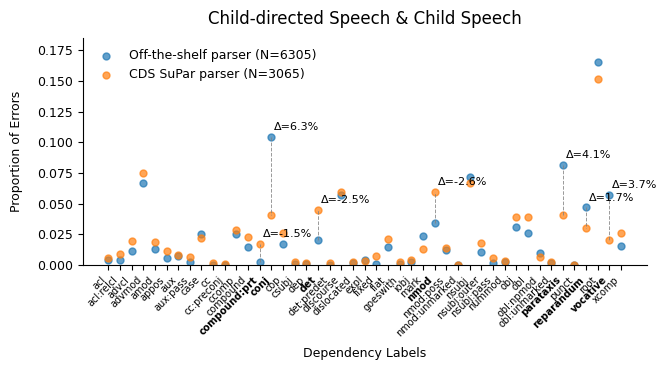

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data configuration ---
MIN_FREQ = 0
DELTA_THRESHOLD = 0.015  # minimum difference to draw a line and annotate

# union of labels
all_labels = set(off_the_shelf) | set(cds_supar)

total_off = sum(off_the_shelf.values())
total_supar = sum(cds_supar.values())

# filter labels by threshold
labels = [
    lbl for lbl in all_labels
    if off_the_shelf.get(lbl, 0) >= MIN_FREQ
    or cds_supar.get(lbl, 0) >= MIN_FREQ
]

labels = sorted(labels)

# x positions
x = np.arange(len(labels))

# y values
y_off = [off_the_shelf.get(lbl, 0) / total_off for lbl in labels]
y_supar = [cds_supar.get(lbl, 0) / total_supar for lbl in labels]

# --- Plotting ---
plt.figure(figsize=(6.8, 3.8), facecolor='white')
ax = plt.gca()

plt.scatter(
    x,
    y_off,
    alpha=0.7,
    s=25,
    label=f"Off-the-shelf parser (N={total_off})"
)

plt.scatter(
    x,
    y_supar,
    alpha=0.7,
    s=25,
    label=f"CDS SuPar parser (N={total_supar})"
)

for i, lbl in enumerate(labels):
    delta = y_off[i] - y_supar[i]
    if abs(delta) > DELTA_THRESHOLD:
        plt.plot(
            [i, i],
            [y_off[i], y_supar[i]],
            linestyle="--",
            linewidth=0.7,
            color="gray",
            alpha=0.8
        )

        y_pos = max(y_off[i], y_supar[i]) + 0.004
        plt.text(
            i + 0.25,
            y_pos,
            f"Δ={delta*100:.1f}%",
            ha="left",
            va="bottom",
            fontsize=8
        )

# --- Clean Layout: Remove Grid and Top/Right Borders ---
plt.grid(False) # Grid deleted
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')

# x-axis labels
plt.xticks(
    x,
    labels,
    rotation=45,
    ha="right",
    fontsize=7
)

# Bold only labels with large deltas
for i, lbl in enumerate(labels):
    delta = y_off[i] - y_supar[i]
    tick_label = ax.get_xticklabels()[i]
    tick_label.set_fontweight('bold' if abs(delta) >= DELTA_THRESHOLD else 'normal')

plt.yticks(fontsize=9)
plt.ylim(0, max(max(y_off), max(y_supar)) + 0.02)
plt.ylabel("Proportion of Errors", fontsize=9, labelpad=10)
plt.xlabel("Dependency Labels", fontsize=9, labelpad=6)
plt.title("Child-directed Speech & Child Speech", fontsize=12, pad=10)

plt.legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig(
    "comparison_proportional_clean.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()

## SCATTERPLOT with all the labels FOR SPEAKER ROLE

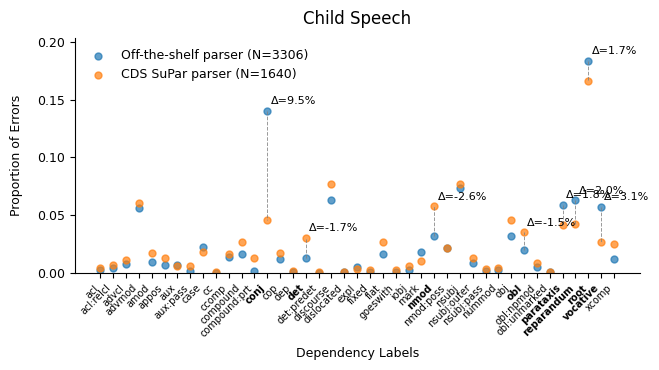

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data configuration ---
off_data = off_the_shelf_child
supar_data = cds_supar_child

MIN_FREQ = 0
DELTA_THRESHOLD = 0.015  # 1.5% threshold for normalization

# Calculate totals for normalization
total_off = sum(off_data.values())
total_supar = sum(supar_data.values())

# Union and filter labels
all_labels = set(off_data) | set(supar_data)
labels = [
    lbl for lbl in all_labels
    if off_data.get(lbl, 0) >= MIN_FREQ
    or supar_data.get(lbl, 0) >= MIN_FREQ
]
labels = sorted(labels)

# X positions
x = np.arange(len(labels))

# Normalized Y values (Proportions)
y_off = [off_data.get(lbl, 0) / total_off for lbl in labels]
y_supar = [supar_data.get(lbl, 0) / total_supar for lbl in labels]

# --- Plotting ---
plt.figure(figsize=(6.8, 3.8), facecolor='white')
ax = plt.gca()

plt.scatter(
    x,
    y_off,
    alpha=0.7,
    s=25,
    label=f"Off-the-shelf parser (N={total_off})"
)

plt.scatter(
    x,
    y_supar,
    alpha=0.7,
    s=25,
    label=f"CDS SuPar parser (N={total_supar})"
)

# Lines and delta annotations
for i, lbl in enumerate(labels):
    delta = y_off[i] - y_supar[i]
    if abs(delta) > DELTA_THRESHOLD:
        plt.plot(
            [i, i],
            [y_off[i], y_supar[i]],
            linestyle="--",
            linewidth=0.7,
            color="gray",
            alpha=0.8
        )

        y_pos = max(y_off[i], y_supar[i]) + 0.004
        plt.text(
            i + 0.25,
            y_pos,
            f"Δ={delta*100:.1f}%",
            ha="left",
            va="bottom",
            fontsize=8
        )

# --- Clean Layout: Remove Grid and Top/Right Spines ---
plt.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')

# --- Axis Formatting ---
plt.xticks(
    x,
    labels,
    rotation=45,
    ha="right",
    fontsize=7
)

# Bold only labels with large deltas
for i, lbl in enumerate(labels):
    delta = y_off[i] - y_supar[i]
    tick_label = ax.get_xticklabels()[i]
    tick_label.set_fontweight('bold' if abs(delta) >= DELTA_THRESHOLD else 'normal')

plt.yticks(fontsize=9)
plt.ylim(0, max(max(y_off), max(y_supar)) + 0.02)
plt.ylabel("Proportion of Errors", fontsize=9, labelpad=10)
plt.xlabel("Dependency Labels", fontsize=9, labelpad=6)
plt.title("Child Speech", fontsize=12, pad=10)

plt.legend(fontsize=9, frameon=False)

plt.tight_layout()
# Save and show
plt.savefig(
    "comparison_child_proportional.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()

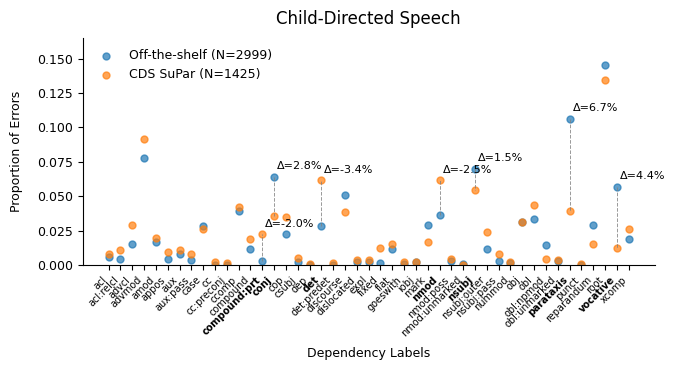

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data configuration ---
off_data = off_the_shelf_adult
supar_data = cds_supar_adult

MIN_FREQ = 0
DELTA_THRESHOLD = 0.015 

total_off = sum(off_data.values())
total_supar = sum(supar_data.values())

all_labels = set(off_data) | set(supar_data)
labels = [
    lbl for lbl in all_labels
    if off_data.get(lbl, 0) >= MIN_FREQ
    or supar_data.get(lbl, 0) >= MIN_FREQ
]
labels = sorted(labels)

x = np.arange(len(labels))
y_off = [off_data.get(lbl, 0) / total_off for lbl in labels]
y_supar = [supar_data.get(lbl, 0) / total_supar for lbl in labels]

# --- Plotting ---
plt.figure(figsize=(6.8, 3.8), facecolor='white')
ax = plt.gca()

plt.scatter(x, y_off, alpha=0.7, s=25, label=f"Off-the-shelf (N={total_off})")
plt.scatter(x, y_supar, alpha=0.7, s=25, label=f"CDS SuPar (N={total_supar})")

for i, lbl in enumerate(labels):
    delta = y_off[i] - y_supar[i]
    if abs(delta) > DELTA_THRESHOLD:
        plt.plot([i, i], [y_off[i], y_supar[i]], linestyle="--", linewidth=0.7, color="gray", alpha=0.8)
        y_pos = max(y_off[i], y_supar[i]) + 0.004
        plt.text(i + 0.25, y_pos, f"Δ={delta*100:.1f}%", ha="left", va="bottom", fontsize=8)

# --- Clean Layout: Remove Grid and specific Spines ---
plt.grid(False)

# Hide the top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Keep the bottom and left axes visible
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)

# Set the axis lines to a subtle gray or black
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

# --- Axis Formatting ---
plt.xticks(x, labels, rotation=45, ha="right", fontsize=7)

for i, lbl in enumerate(labels):
    delta = y_off[i] - y_supar[i]
    tick_label = ax.get_xticklabels()[i]
    tick_label.set_fontweight('bold' if abs(delta) >= DELTA_THRESHOLD else 'normal')

plt.yticks(fontsize=9)
plt.ylim(0, max(max(y_off), max(y_supar)) + 0.02)
plt.ylabel("Proportion of Errors", fontsize=9, labelpad=10)
plt.xlabel("Dependency Labels", fontsize=9, labelpad=6)
plt.title("Child-Directed Speech", fontsize=12, pad=10)

plt.legend(fontsize=9, frameon=False)

plt.tight_layout()

# Save as PDF for high quality
plt.savefig(
    "comparison_cds_proportional.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()

## CONFUSION MATRIX

In [15]:
from collections import defaultdict
from conllu import parse_incr

def load_labels_from_conllu(file_path):
    """
    Load dependency labels from a CoNLL-U file.
    Returns a list of gold labels and predicted labels.
    For gold file, both lists are the same.
    """
    gold_labels = []
    
    with open(file_path, "r", encoding="utf-8") as f:
        for tokenlist in parse_incr(f):
            for token in tokenlist:
                # skip multi-word tokens and empty nodes
                if isinstance(token["id"], tuple) or isinstance(token["id"], float):
                    continue
                gold_labels.append(token["deprel"])
    
    return gold_labels

In [16]:
from collections import Counter

def get_gold_label_counts(gold_path):
    """Return Counter with frequency of each gold label."""
    gold_sents = load_conllu_gold(gold_path)  # your existing function
    counter = Counter()
    for sent in gold_sents:
        for tok in sent:
            counter[tok["deprel"]] += 1
    return counter


In [17]:
from sklearn.metrics import confusion_matrix
import pandas as pd

def build_confusion_matrix(gold_path, pred_path, labels_to_keep=None):
    gold_sents = load_conllu_gold(gold_path)
    pred_sents = load_conllu_gold(pred_path)
    
    assert len(gold_sents) == len(pred_sents), "Sentence count mismatch"
    
    # collect all labels if not provided
    if labels_to_keep is None:
        labels_to_keep = sorted(list({t["deprel"] for s in gold_sents for t in s}))
    
    # initialize confusion matrix
    cm_df = pd.DataFrame(0, index=labels_to_keep, columns=labels_to_keep)
    
    for g_sent, p_sent in zip(gold_sents, pred_sents):
        # we assume gold and prediction tokenization align perfectly
        assert len(g_sent) == len(p_sent), "Token count mismatch in sentence"
        for g_tok, p_tok in zip(g_sent, p_sent):
            gold_label = g_tok["deprel"]
            pred_label = p_tok["deprel"]
            if gold_label in labels_to_keep and pred_label in labels_to_keep:
                cm_df.loc[gold_label, pred_label] += 1
                
    return cm_df



In [18]:
def filter_by_error_count(cm_off, cm_supar, min_errors=10):
    """
    Filter out labels that have fewer than min_errors total misclassifications
    across both parsers.
    
    Parameters:
    -----------
    cm_off : DataFrame
        Confusion matrix for off-the-shelf parser
    cm_supar : DataFrame
        Confusion matrix for supar parser
    min_errors : int
        Minimum number of total errors required to keep a label
    
    Returns:
    --------
    labels_to_keep : list
        Labels that meet the error threshold
    """
    labels_to_keep = []
    
    for label in cm_off.index:
        # Count total errors for this label (row errors + column errors - diagonal)
        # Row errors: when gold=label but predicted something else
        row_errors_off = cm_off.loc[label, :].sum() - cm_off.loc[label, label]
        row_errors_supar = cm_supar.loc[label, :].sum() - cm_supar.loc[label, label]
        
        # Column errors: when predicted=label but gold was something else
        col_errors_off = cm_off.loc[:, label].sum() - cm_off.loc[label, label]
        col_errors_supar = cm_supar.loc[:, label].sum() - cm_supar.loc[label, label]
        
        # Total errors involving this label
        total_errors = row_errors_off + row_errors_supar + col_errors_off + col_errors_supar
        
        if total_errors >= min_errors:
            labels_to_keep.append(label)
    
    return labels_to_keep

def filter_by_error_frequency(cm_off, cm_supar, min_error_rate=0.01):
    """
    Alternative: Filter by error rate (percentage of total errors).
    
    Parameters:
    -----------
    min_error_rate : float
        Minimum proportion of total errors (e.g., 0.01 = 1%)
    """
    # Calculate total errors for each parser
    total_errors_off = 0
    total_errors_supar = 0
    
    for i in range(len(cm_off)):
        for j in range(len(cm_off)):
            if i != j:
                total_errors_off += cm_off.iloc[i, j]
                total_errors_supar += cm_supar.iloc[i, j]
    
    labels_to_keep = []
    
    for label in cm_off.index:
        # Count errors for this label
        row_errors_off = cm_off.loc[label, :].sum() - cm_off.loc[label, label]
        row_errors_supar = cm_supar.loc[label, :].sum() - cm_supar.loc[label, label]
        col_errors_off = cm_off.loc[:, label].sum() - cm_off.loc[label, label]
        col_errors_supar = cm_supar.loc[:, label].sum() - cm_supar.loc[label, label]
        
        total_label_errors = row_errors_off + row_errors_supar + col_errors_off + col_errors_supar
        total_all_errors = total_errors_off + total_errors_supar
        
        error_rate = total_label_errors / total_all_errors if total_all_errors > 0 else 0
        
        if error_rate >= min_error_rate:
            labels_to_keep.append(label)
    
    return labels_to_keep


## NEW MATRIX

In [19]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

def load_conllu_gold(file_path):
    """Load CoNLL-U file and return list of sentences (list of token dicts)."""
    from conllu import parse_incr
    sents = []
    with open(file_path, "r", encoding="utf-8") as f:
        for tokenlist in parse_incr(f):
            tokens = []
            for token in tokenlist:
                if isinstance(token["id"], tuple) or isinstance(token["id"], float):
                    continue
                tokens.append(token)
            sents.append(tokens)
    return sents

def get_gold_label_counts(gold_path):
    """Return Counter with frequency of each gold label."""
    gold_sents = load_conllu_gold(gold_path)
    counter = Counter()
    for sent in gold_sents:
        for tok in sent:
            counter[tok["deprel"]] += 1
    return counter

def build_confusion_matrix(gold_path, pred_path, labels_to_keep=None):
    """Build confusion matrix as DataFrame."""
    gold_sents = load_conllu_gold(gold_path)
    pred_sents = load_conllu_gold(pred_path)
    
    assert len(gold_sents) == len(pred_sents), "Sentence count mismatch"
    
    if labels_to_keep is None:
        labels_to_keep = sorted(list({t["deprel"] for s in gold_sents for t in s}))
    
    cm_df = pd.DataFrame(0, index=labels_to_keep, columns=labels_to_keep)
    
    for g_sent, p_sent in zip(gold_sents, pred_sents):
        assert len(g_sent) == len(p_sent), "Token count mismatch in sentence"
        for g_tok, p_tok in zip(g_sent, p_sent):
            gold_label = g_tok["deprel"]
            pred_label = p_tok["deprel"]
            if gold_label in labels_to_keep and pred_label in labels_to_keep:
                cm_df.loc[gold_label, pred_label] += 1
                
    return cm_df

def filter_by_error_count(cm_off, cm_supar, min_errors=100):
    """
    Keep labels whose total errors (off-diagonal counts)
    across both systems are >= min_errors.
    """
    labels_to_keep = []

    for label in cm_off.index:
        # Errors = row sum - diagonal
        off_errors = cm_off.loc[label].sum() - cm_off.loc[label, label]
        supar_errors = cm_supar.loc[label].sum() - cm_supar.loc[label, label]

        total_errors = off_errors + supar_errors

        if total_errors >= min_errors:
            labels_to_keep.append(label)

    return labels_to_keep

def normalize_errors(cm_df):
    """
    Normalize off-diagonal errors over total misclassifications.
    Diagonal stays unchanged (correct predictions).
    Returns normalized confusion matrix.
    """
    cm_normalized = cm_df.copy()
    
    # Calculate total errors (sum of off-diagonal elements)
    total_errors = 0
    for i in range(len(cm_df)):
        for j in range(len(cm_df)):
            if i != j:  # off-diagonal
                total_errors += cm_df.iloc[i, j]
    
    # Normalize off-diagonal elements
    if total_errors > 0:
        for i in range(len(cm_df)):
            for j in range(len(cm_df)):
                if i != j:  # only normalize errors, not correct predictions
                    cm_normalized.iloc[i, j] = cm_df.iloc[i, j] / total_errors
    
    return cm_normalized

def compute_delta_matrix(cm_off_norm, cm_supar_norm):
    """
    Compute delta matrix: supar errors - off-the-shelf errors.
    Positive values mean supar makes more errors of that type.
    Negative values mean off-the-shelf makes more errors of that type.
    Diagonal is set to 0 (we only care about error differences).
    """
    delta = cm_supar_norm - cm_off_norm
    
    # Set diagonal to 0 (we don't care about correct prediction differences)
    np.fill_diagonal(delta.values, 0)
    
    return delta


def plot_delta_confusion_matrix(delta_df, title="Delta Error Matrix (SuPar - Off-the-shelf)", 
                                 as_percentage=True, save_path=''):
    """
    Plot delta confusion matrix with diverging colormap.
    Negative (blue) = off-the-shelf makes more errors
    Positive (red) = supar makes more errors
    
    Parameters:
    -----------
    as_percentage : bool
        If True, multiply by 100 and show as percentages
    save_path : str
        Path to save the figure as PDF
    """
    # Create mask for diagonal
    mask = np.eye(delta_df.shape[0], dtype=bool)
    
    # Convert to percentage if requested
    if as_percentage:
        display_df = delta_df * 100
        fmt_string = ".2f"
        cbar_label = 'Error Rate Difference (%)'
    else:
        display_df = delta_df
        fmt_string = ".4f"
        cbar_label = 'Error Rate Difference'
    
    # Find max absolute value for symmetric colorbar
    vmax = np.abs(display_df.values[~mask]).max()
    
    fig, ax = plt.subplots(figsize=(16, 14))
    
    heatmap = sns.heatmap(
        display_df,
        mask=mask,
        annot=True,
        fmt=fmt_string,
        cmap="RdBu_r",
        center=0,
        vmin=-vmax,
        vmax=vmax,
        cbar_kws={'label': ''},  # Empty for now
        annot_kws={"size": 10},
        linewidths=0.5,
        ax=ax
    )
    
    # Get colorbar and set label with larger font
    cbar = heatmap.collections[0].colorbar
    cbar.set_label(cbar_label, size=16)
    
    # Add zeros on diagonal
    for i in range(display_df.shape[0]):
        plt.text(
            i + 0.5, i + 0.5, "0",
            ha="center", va="center", color="gray", fontsize=10, weight='bold'
        )
    
    plt.title(title, fontsize=21, pad=20)
    plt.ylabel("Gold label", fontsize=17)
    plt.xlabel("Predicted label", fontsize=17)
    plt.yticks(rotation=0, fontsize=12)
    plt.xticks(rotation=45, ha="right", fontsize=12)
    plt.tight_layout()
    
    # Save as PDF if path is provided
    if save_path:
        plt.savefig(save_path, format='pdf', dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    
    plt.show()


Total unique gold labels: 45
Labels with at least 100 gold instances: 30
Building confusion matrices...
Labels after error count filter: 30

Normalizing errors...
Computing delta matrix...

Plotting delta confusion matrix...


/var/folders/hf/t5b8jlfd4lz04bzl35ccq5mm0000gn/T/ipykernel_38470/953825578.py:91: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.00017397355601948505' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cm_normalized.iloc[i, j] = cm_df.iloc[i, j] / total_errors
/var/folders/hf/t5b8jlfd4lz04bzl35ccq5mm0000gn/T/ipykernel_38470/953825578.py:91: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.0005219206680584551' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cm_normalized.iloc[i, j] = cm_df.iloc[i, j] / total_errors
/var/folders/hf/t5b8jlfd4lz04bzl35ccq5mm0000gn/T/ipykernel_38470/953825578.py:91: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.00017397355601948505' 

Figure saved to: delta_confusion_matrix.pdf


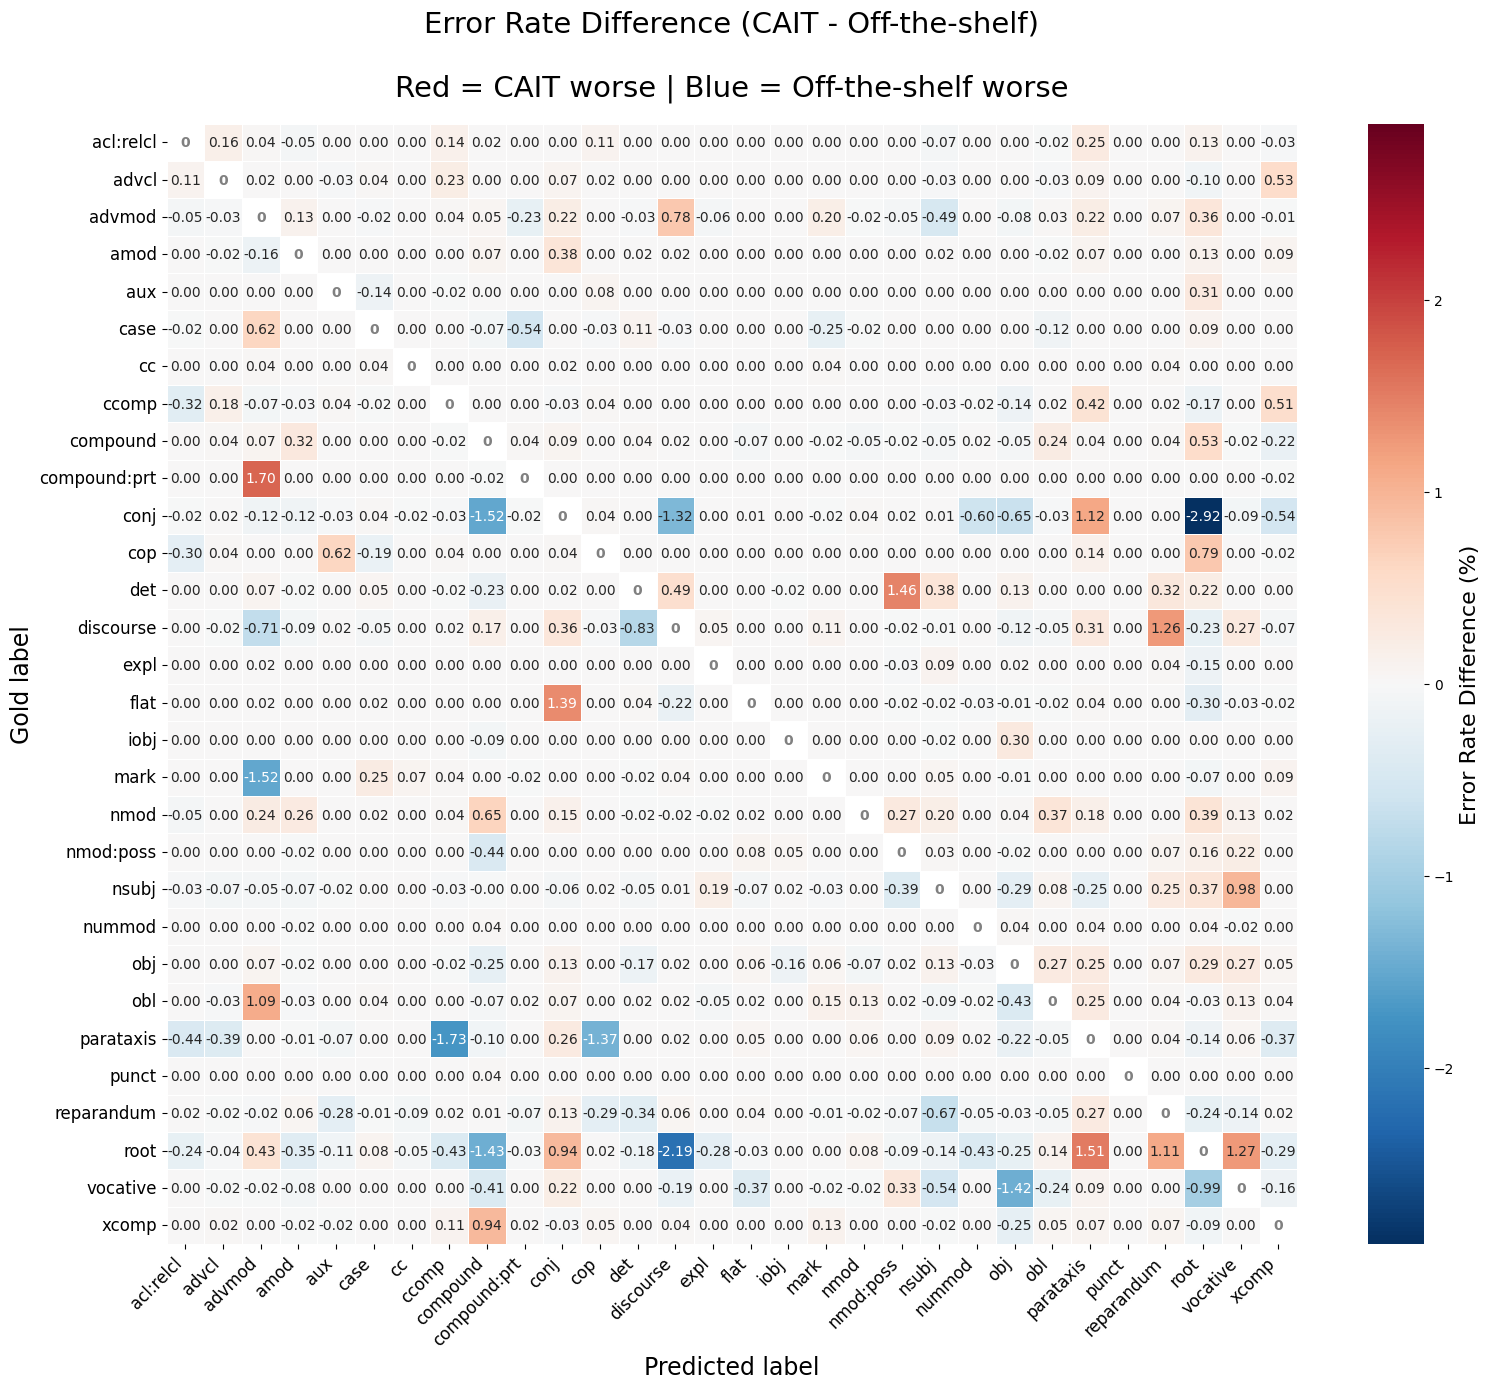

In [32]:
# Updated main execution
gold_file = "/Users/frapadovani/Desktop/CHILDES-Parser/UD_English-CHILDES/en_childes-ud-test.conllu"
pred_file_off = "/Users/frapadovani/Desktop/CHILDES-Parser/eval_scripts/prediction_files_integral/off_the_shelf_stanza_test.conllu"
pred_file_supar = "/Users/frapadovani/Desktop/CHILDES-Parser/eval_scripts/prediction_files_integral/supar_childes_roberta.conllu"
MIN_GOLD_FREQ = 100

# Get label counts and sort
gold_counts = get_gold_label_counts(gold_file)
print(f"Total unique gold labels: {len(gold_counts)}")
labels_with_enough_gold = [
    lbl for lbl, count in gold_counts.items()
    if count >= MIN_GOLD_FREQ
]
# Keep original frequency order
sorted_labels = [
    lbl for lbl, _ in gold_counts.most_common()
    if lbl in labels_with_enough_gold
][::-1]
sorted_labels = sorted(sorted_labels)  # sort alphabetically for matrix
print(f"Labels with at least {MIN_GOLD_FREQ} gold instances: {len(sorted_labels)}")

# Build initial confusion matrices
print("Building confusion matrices...")
cm_off = build_confusion_matrix(gold_file, pred_file_off, labels_to_keep=sorted_labels)
cm_supar = build_confusion_matrix(gold_file, pred_file_supar, labels_to_keep=sorted_labels)

'''MIN_ERROR_COUNT = 50
labels_final = filter_by_error_count(
    cm_off,
    cm_supar,
    min_errors=MIN_ERROR_COUNT
)

labels_final = sorted(sorted_labels)

cm_off_final = cm_off.loc[labels_final, labels_final]
cm_supar_final = cm_supar.loc[labels_final, labels_final]'''

labels_final = sorted(sorted_labels)
print(f"Labels after error count filter: {len(sorted_labels)}")

# Step 3: Normalize errors
print("\nNormalizing errors...")
cm_off_norm = normalize_errors(cm_off)
cm_supar_norm = normalize_errors(cm_supar)

# Step 4: Compute delta matrix
print("Computing delta matrix...")
delta_matrix = compute_delta_matrix(cm_off_norm, cm_supar_norm)

# Plot delta matrix
print("\nPlotting delta confusion matrix...")
plot_delta_confusion_matrix(
    delta_matrix, 
    title="Error Rate Difference (CAIT - Off-the-shelf)\n\nRed = CAIT worse | Blue = Off-the-shelf worse",
    as_percentage=True,
    save_path="delta_confusion_matrix.pdf"
)



Figure saved to: confusion_matrix_off_the_shelf.pdf


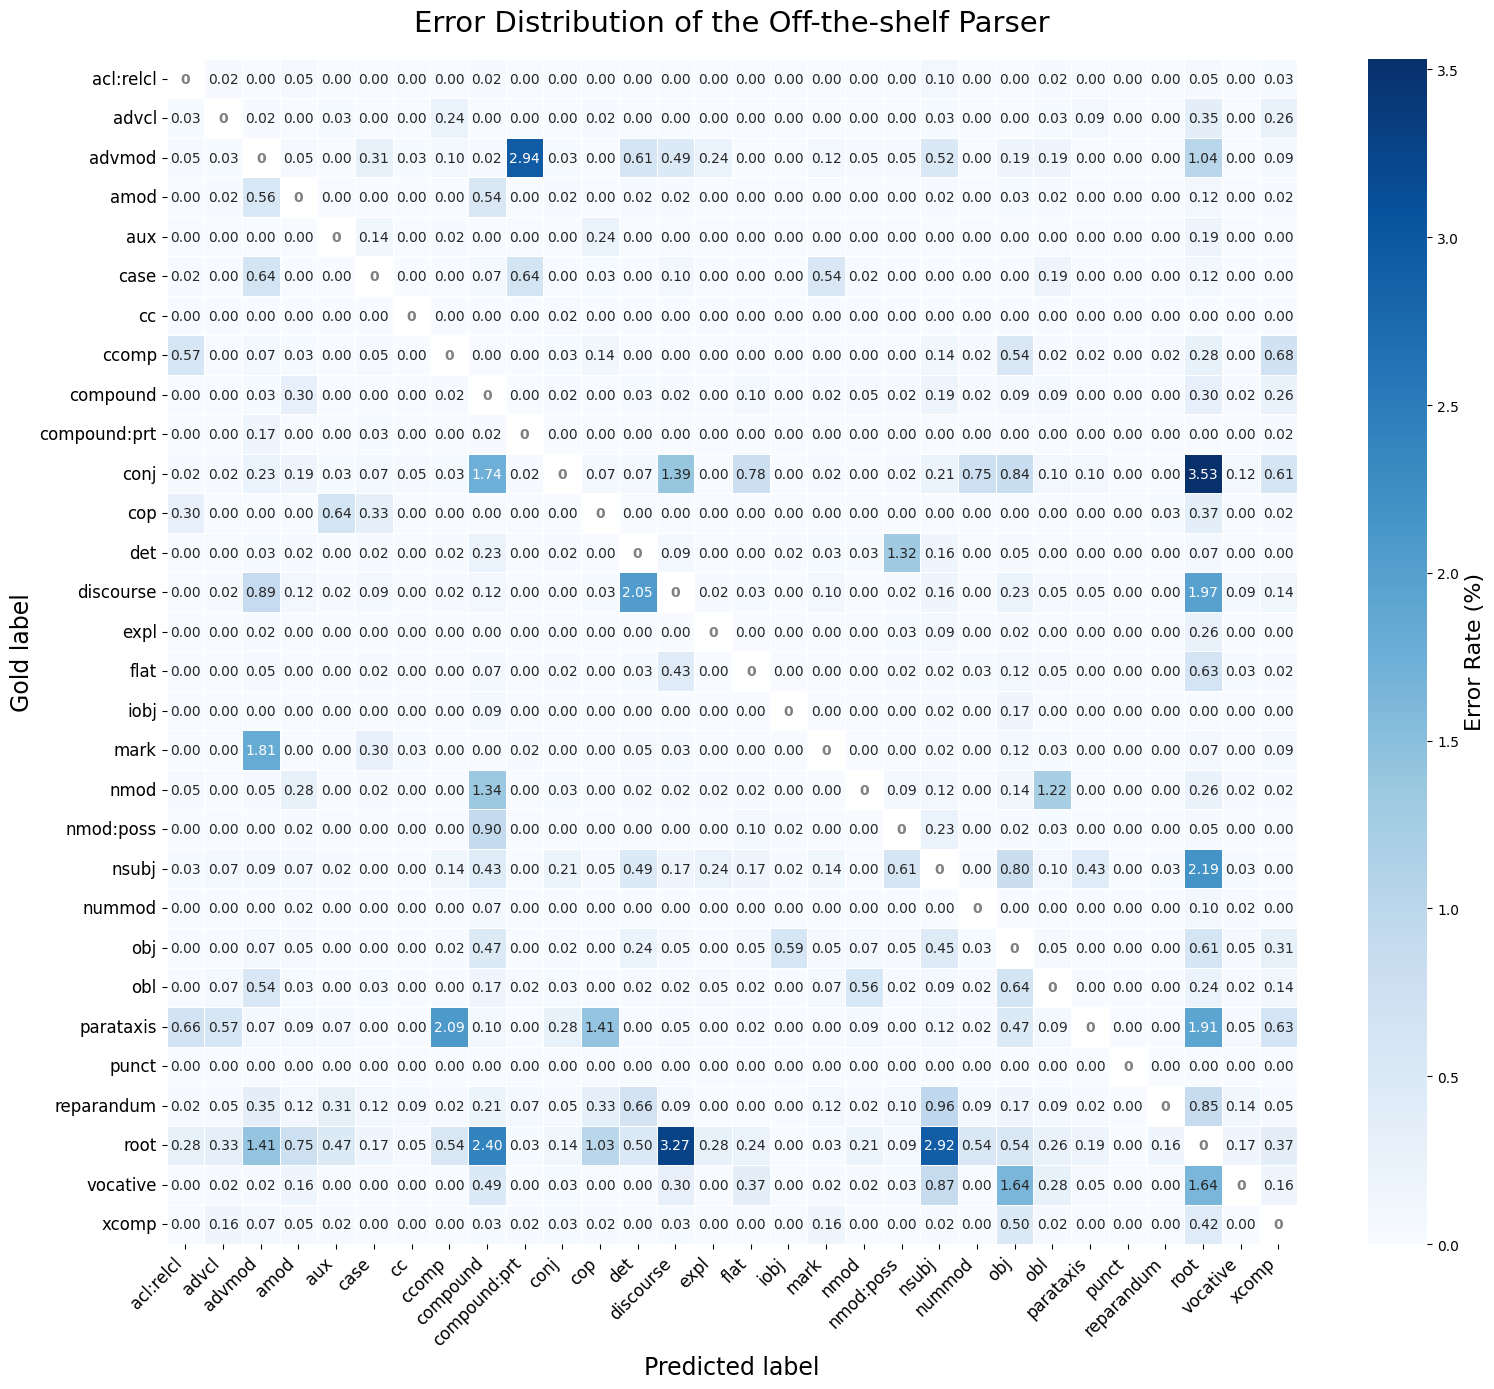

Figure saved to: confusion_matrix_cait.pdf


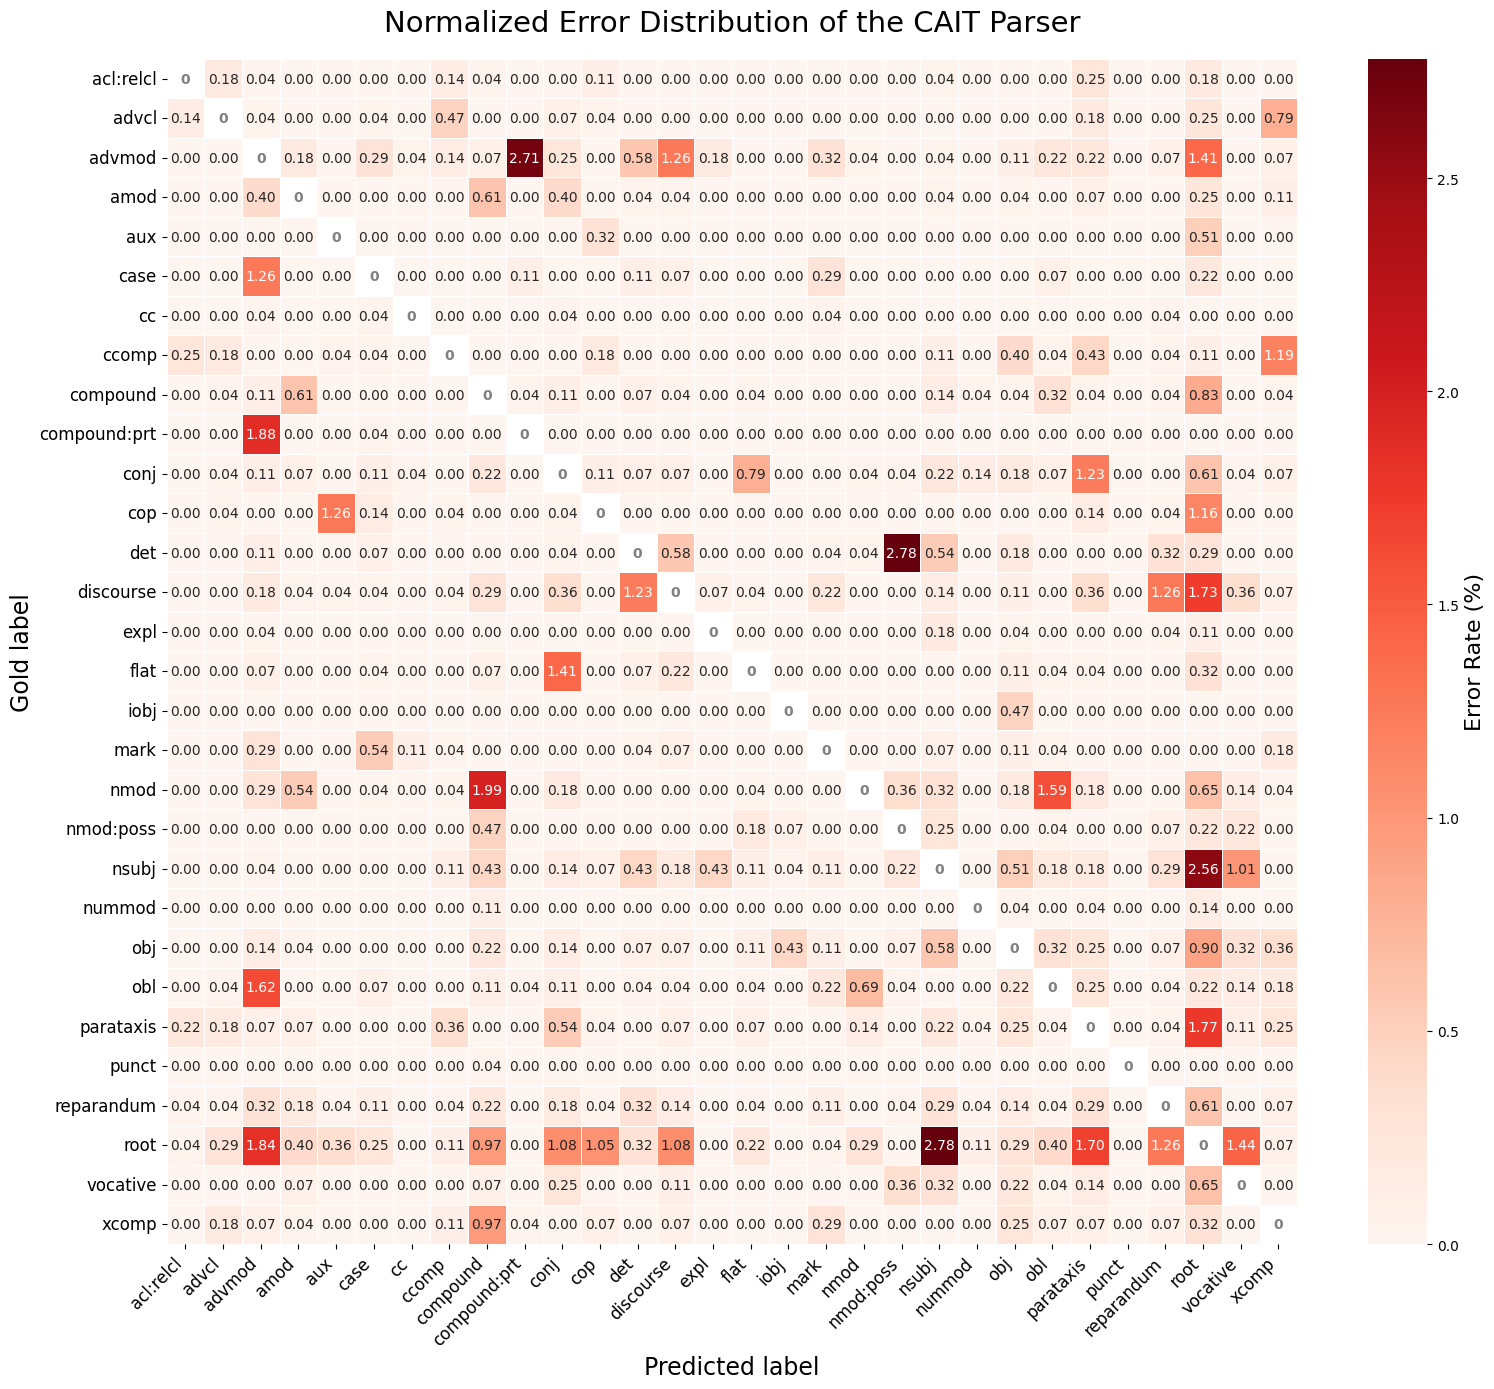

In [30]:
def plot_single_confusion_matrix(cm_norm_df, title="", as_percentage=True, save_path='',cmap="Reds"):
    """
    Plot a single normalized confusion matrix.
    Diagonal is masked (correct predictions not shown).
    """
    mask = np.eye(cm_norm_df.shape[0], dtype=bool)

    if as_percentage:
        display_df = cm_norm_df * 100
        fmt_string = ".2f"
        cbar_label = 'Error Rate (%)'
    else:
        display_df = cm_norm_df
        fmt_string = ".4f"
        cbar_label = 'Error Rate'

    # Set diagonal to NaN for display purposes
    display_df_masked = display_df.copy()
    for i in range(len(display_df_masked)):
        display_df_masked.iloc[i, i] = np.nan

    vmax = np.nanmax(display_df_masked.values)

    fig, ax = plt.subplots(figsize=(16, 14))

    heatmap = sns.heatmap(
        display_df_masked,
        mask=mask,
        annot=True,
        fmt=fmt_string,
        cmap=cmap,
        vmin=0,
        vmax=vmax,
        cbar_kws={'label': ''},
        annot_kws={"size": 10},
        linewidths=0.5,
        ax=ax
    )

    cbar = heatmap.collections[0].colorbar
    cbar.set_label(cbar_label, size=16)

    # Add zeros on diagonal
    for i in range(display_df.shape[0]):
        plt.text(
            i + 0.5, i + 0.5, "0",
            ha="center", va="center", color="gray", fontsize=10, weight='bold'
        )

    plt.title(title, fontsize=21, pad=20)
    plt.ylabel("Gold label", fontsize=17)
    plt.xlabel("Predicted label", fontsize=17)
    plt.yticks(rotation=0, fontsize=12)
    plt.xticks(rotation=45, ha="right", fontsize=12)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='pdf', dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")

    plt.show()


# --- Main execution ---
# (reuse cm_off_norm and cm_supar_norm from your existing pipeline)

plot_single_confusion_matrix(
    pd.DataFrame(cm_off_norm, index=labels_final, columns=labels_final),
    title="Error Distribution of the Off-the-shelf Parser",
    as_percentage=True,
    save_path="confusion_matrix_off_the_shelf.pdf",
    cmap="Blues"
)

plot_single_confusion_matrix(
    pd.DataFrame(cm_supar_norm, index=labels_final, columns=labels_final),
    title="Normalized Error Distribution of the CAIT Parser",
    as_percentage=True,
    save_path="confusion_matrix_cait.pdf",
    cmap="Reds"
)

30


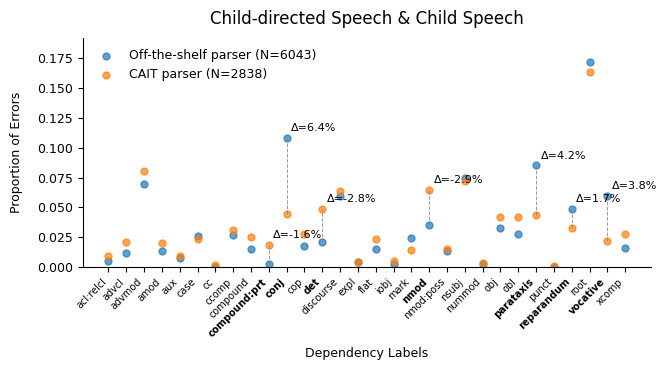


Scatterplot generated using filtered labels:
Total labels: 30
['acl:relcl', 'advcl', 'advmod', 'amod', 'aux', 'case', 'cc', 'ccomp', 'compound', 'compound:prt', 'conj', 'cop', 'det', 'discourse', 'expl', 'flat', 'iobj', 'mark', 'nmod', 'nmod:poss', 'nsubj', 'nummod', 'obj', 'obl', 'parataxis', 'punct', 'reparandum', 'root', 'vocative', 'xcomp']


In [61]:
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------
# IMPORTANT:
# Assumes `labels_final` has already been computed
# from your gold ≥ 25 and error ≥ 50 filtering.
# --------------------------------------------------

DELTA_THRESHOLD = 0.015

labels = sorted(labels_final)
print(len(labels))

# Compute totals ONLY over filtered labels
total_off = sum(off_the_shelf.get(lbl, 0) for lbl in labels)
total_supar = sum(cds_supar.get(lbl, 0) for lbl in labels)

# x positions
x = np.arange(len(labels))

# y values (normalized over filtered labels only)
y_off = [
    off_the_shelf.get(lbl, 0) / total_off if total_off > 0 else 0
    for lbl in labels
]

y_supar = [
    cds_supar.get(lbl, 0) / total_supar if total_supar > 0 else 0
    for lbl in labels
]

# --- Plotting ---
plt.figure(figsize=(6.8, 3.8), facecolor='white')
ax = plt.gca()

plt.scatter(
    x,
    y_off,
    alpha=0.7,
    s=25,
    label=f"Off-the-shelf parser (N={total_off})"
)

plt.scatter(
    x,
    y_supar,
    alpha=0.7,
    s=25,
    label=f"CAIT parser (N={total_supar})"
)

# Draw delta lines for meaningful differences
for i, lbl in enumerate(labels):
    delta = y_off[i] - y_supar[i]
    if abs(delta) > DELTA_THRESHOLD:
        plt.plot(
            [i, i],
            [y_off[i], y_supar[i]],
            linestyle="--",
            linewidth=0.7,
            color="gray",
            alpha=0.8
        )

        y_pos = max(y_off[i], y_supar[i]) + 0.004
        plt.text(
            i + 0.25,
            y_pos,
            f"Δ={delta*100:.1f}%",
            ha="left",
            va="bottom",
            fontsize=8
        )

# --- Clean Layout ---
plt.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')

# x-axis labels
plt.xticks(
    x,
    labels,
    rotation=45,
    ha="right",
    fontsize=7
)

# Bold labels with large deltas
for i, lbl in enumerate(labels):
    delta = y_off[i] - y_supar[i]
    tick_label = ax.get_xticklabels()[i]
    tick_label.set_fontweight('bold' if abs(delta) >= DELTA_THRESHOLD else 'normal')

plt.yticks(fontsize=9)
plt.ylim(0, max(max(y_off), max(y_supar)) + 0.02)
plt.ylabel("Proportion of Errors", fontsize=9, labelpad=10)
plt.xlabel("Dependency Labels", fontsize=9, labelpad=6)
plt.title("Child-directed Speech & Child Speech", fontsize=12, pad=10)

plt.legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig(
    "comparison_proportional_clean.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()

print("\nScatterplot generated using filtered labels:")
print(f"Total labels: {len(labels)}")
print(labels)


## NORMALIZED BY THE TOKEN FREQUENCY

30


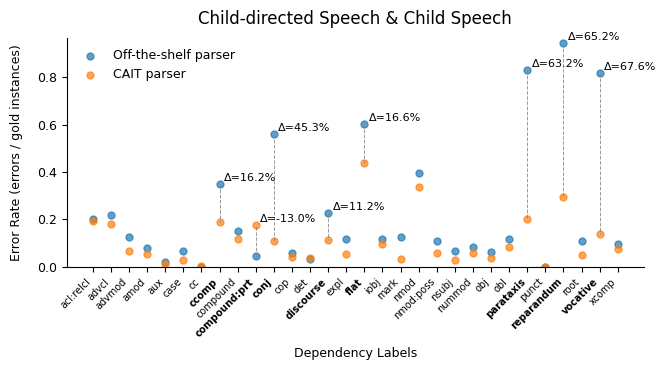


Scatterplot generated using filtered labels:
Total labels: 30
['acl:relcl', 'advcl', 'advmod', 'amod', 'aux', 'case', 'cc', 'ccomp', 'compound', 'compound:prt', 'conj', 'cop', 'det', 'discourse', 'expl', 'flat', 'iobj', 'mark', 'nmod', 'nmod:poss', 'nsubj', 'nummod', 'obj', 'obl', 'parataxis', 'punct', 'reparandum', 'root', 'vocative', 'xcomp']


In [23]:
import matplotlib.pyplot as plt
import numpy as np

DELTA_THRESHOLD = 0.1

labels = sorted(labels_final)
print(len(labels))

# Normalize each parser's errors by the gold count for that label
y_off = [
    off_the_shelf.get(lbl, 0) / gold_counts[lbl] if gold_counts.get(lbl, 0) > 0 else 0
    for lbl in labels
]

y_supar = [
    cds_supar.get(lbl, 0) / gold_counts[lbl] if gold_counts.get(lbl, 0) > 0 else 0
    for lbl in labels
]

# x positions
x = np.arange(len(labels))

# --- Plotting ---
plt.figure(figsize=(6.8, 3.8), facecolor='white')
ax = plt.gca()

plt.scatter(
    x,
    y_off,
    alpha=0.7,
    s=25,
    label="Off-the-shelf parser"
)

plt.scatter(
    x,
    y_supar,
    alpha=0.7,
    s=25,
    label="CAIT parser"
)

# Draw delta lines for meaningful differences
for i, lbl in enumerate(labels):
    delta = y_off[i] - y_supar[i]
    if abs(delta) > DELTA_THRESHOLD:
        plt.plot(
            [i, i],
            [y_off[i], y_supar[i]],
            linestyle="--",
            linewidth=0.7,
            color="gray",
            alpha=0.8
        )

        y_pos = max(y_off[i], y_supar[i]) + 0.004
        plt.text(
            i + 0.25,
            y_pos,
            f"Δ={delta*100:.1f}%",
            ha="left",
            va="bottom",
            fontsize=8
        )

# --- Clean Layout ---
plt.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')

# x-axis labels
plt.xticks(
    x,
    labels,
    rotation=45,
    ha="right",
    fontsize=7
)

# Bold labels with large deltas
for i, lbl in enumerate(labels):
    delta = y_off[i] - y_supar[i]
    tick_label = ax.get_xticklabels()[i]
    tick_label.set_fontweight('bold' if abs(delta) >= DELTA_THRESHOLD else 'normal')

plt.yticks(fontsize=9)
plt.ylim(0, max(max(y_off), max(y_supar)) + 0.02)
plt.ylabel("Error Rate (errors / gold instances)", fontsize=9, labelpad=10)
plt.xlabel("Dependency Labels", fontsize=9, labelpad=6)
plt.title("Child-directed Speech & Child Speech", fontsize=12, pad=10)

plt.legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig(
    "comparison_error_rate.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()

print("\nScatterplot generated using filtered labels:")
print(f"Total labels: {len(labels)}")
print(labels)

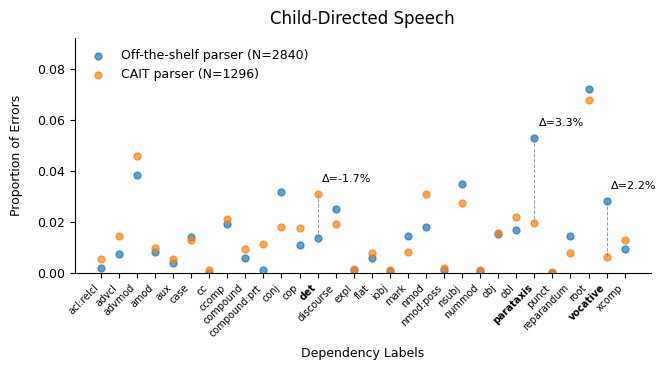

In [65]:
import matplotlib.pyplot as plt
import numpy as np


DELTA_THRESHOLD = 0.015

labels = sorted(labels_final)


# Compute totals ONLY over filtered labels
total_off_adult = sum(off_the_shelf_adult.get(lbl, 0) for lbl in labels)
total_supar_adult = sum(cds_supar_adult.get(lbl, 0) for lbl in labels)


x = np.arange(len(labels))
y_off = [off_the_shelf_adult.get(lbl, 0) / total_off for lbl in labels]
y_supar = [cds_supar_adult.get(lbl, 0) / total_supar for lbl in labels]

# --- Plotting ---
plt.figure(figsize=(6.8, 3.8), facecolor='white')
ax = plt.gca()

plt.scatter(x, y_off, alpha=0.7, s=25, label=f"Off-the-shelf parser (N={total_off_adult})")
plt.scatter(x, y_supar, alpha=0.7, s=25, label=f"CAIT parser (N={total_supar_adult})")

for i, lbl in enumerate(labels):
    delta = y_off[i] - y_supar[i]
    if abs(delta) > DELTA_THRESHOLD:
        plt.plot([i, i], [y_off[i], y_supar[i]], linestyle="--", linewidth=0.7, color="gray", alpha=0.8)
        y_pos = max(y_off[i], y_supar[i]) + 0.004
        plt.text(i + 0.25, y_pos, f"Δ={delta*100:.1f}%", ha="left", va="bottom", fontsize=8)

# --- Clean Layout: Remove Grid and specific Spines ---
plt.grid(False)

# Hide the top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Keep the bottom and left axes visible
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)

# Set the axis lines to a subtle gray or black
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

# --- Axis Formatting ---
plt.xticks(x, labels, rotation=45, ha="right", fontsize=7)

for i, lbl in enumerate(labels):
    delta = y_off[i] - y_supar[i]
    tick_label = ax.get_xticklabels()[i]
    tick_label.set_fontweight('bold' if abs(delta) >= DELTA_THRESHOLD else 'normal')

plt.yticks(fontsize=9)
plt.ylim(0, max(max(y_off), max(y_supar)) + 0.02)
plt.ylabel("Proportion of Errors", fontsize=9, labelpad=10)
plt.xlabel("Dependency Labels", fontsize=9, labelpad=6)
plt.title("Child-Directed Speech", fontsize=12, pad=10)

plt.legend(fontsize=9, frameon=False, loc="upper left")

plt.tight_layout()

# Save as PDF for high quality
plt.savefig(
    "comparison_cds_proportional.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()

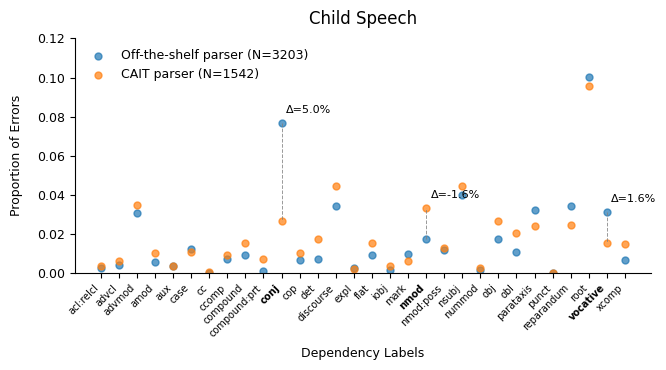

In [66]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data configuration ---
off_data = off_the_shelf_child
supar_data = cds_supar_child

labels = sorted(labels_final)

# Compute totals ONLY over filtered labels
total_off_child = sum(off_the_shelf_child.get(lbl, 0) for lbl in labels)
total_supar_child = sum(cds_supar_child.get(lbl, 0) for lbl in labels)

x = np.arange(len(labels))
y_off = [off_data.get(lbl, 0) / total_off for lbl in labels]
y_supar = [supar_data.get(lbl, 0) / total_supar for lbl in labels]

# --- Plotting ---
plt.figure(figsize=(6.8, 3.8), facecolor='white')
ax = plt.gca()

plt.scatter(x, y_off, alpha=0.7, s=25, label=f"Off-the-shelf parser (N={total_off_child})")
plt.scatter(x, y_supar, alpha=0.7, s=25, label=f"CAIT parser (N={total_supar_child})")

for i, lbl in enumerate(labels):
    delta = y_off[i] - y_supar[i]
    if abs(delta) > DELTA_THRESHOLD:
        plt.plot([i, i], [y_off[i], y_supar[i]], linestyle="--", linewidth=0.7, color="gray", alpha=0.8)
        y_pos = max(y_off[i], y_supar[i]) + 0.004
        plt.text(i + 0.25, y_pos, f"Δ={delta*100:.1f}%", ha="left", va="bottom", fontsize=8)

# --- Clean Layout: Remove Grid and specific Spines ---
plt.grid(False)

# Hide the top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Keep the bottom and left axes visible
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)

# Set the axis lines to a subtle gray or black
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

# --- Axis Formatting ---
plt.xticks(x, labels, rotation=45, ha="right", fontsize=7)

for i, lbl in enumerate(labels):
    delta = y_off[i] - y_supar[i]
    tick_label = ax.get_xticklabels()[i]
    tick_label.set_fontweight('bold' if abs(delta) >= DELTA_THRESHOLD else 'normal')

plt.yticks(fontsize=9)
plt.ylim(0, max(max(y_off), max(y_supar)) + 0.02)
plt.ylabel("Proportion of Errors", fontsize=9, labelpad=10)
plt.xlabel("Dependency Labels", fontsize=9, labelpad=6)
plt.title("Child Speech", fontsize=12, pad=10)

plt.legend(fontsize=9, frameon=False)

plt.tight_layout()

# Save as PDF for high quality
plt.savefig(
    "comparison_cs_proportional.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()

In [34]:
from conllu import parse_incr

def get_gold_counts(filepath):
    counts = {}
    with open(filepath, "r", encoding="utf-8") as f:
        for tokenlist in parse_incr(f):
            for token in tokenlist:
                if isinstance(token["id"], int):  # skip multiword tokens
                    deprel = token["deprel"]
                    if deprel:
                        counts[deprel] = counts.get(deprel, 0) + 1
    return counts

gold_counts_cds = get_gold_counts(
    "/Users/frapadovani/Desktop/CHILDES-Parser/UD_English-CHILDES/en_childes-ud-test_adults.conllu"
)
gold_counts_cs = get_gold_counts(
    "/Users/frapadovani/Desktop/CHILDES-Parser/UD_English-CHILDES/en_childes-ud-test_childes.conllu"
)

print("CDS gold counts:", gold_counts_cds)
print("CS gold counts:", gold_counts_cs)

CDS gold counts: {'root': 4599, 'vocative': 216, 'punct': 4600, 'nsubj': 4129, 'cop': 1221, 'det': 2068, 'parataxis': 402, 'conj': 495, 'aux': 1652, 'amod': 576, 'obj': 1778, 'discourse': 912, 'advmod': 2007, 'nummod': 71, 'case': 1430, 'compound': 259, 'obl': 848, 'nmod:poss': 390, 'nmod': 320, 'xcomp': 601, 'cc': 565, 'compound:prt': 177, 'mark': 746, 'advcl': 240, 'acl': 39, 'iobj': 68, 'obl:unmarked': 73, 'nsubj:outer': 37, 'expl': 110, 'aux:pass': 37, 'nsubj:pass': 32, 'ccomp': 329, 'appos': 21, 'acl:relcl': 94, 'fixed': 25, 'obl:npmod': 43, 'csubj': 7, 'reparandum': 94, 'flat': 70, 'cc:preconj': 4, 'det:predet': 24, 'nmod:unmarked': 3, 'dislocated': 6, 'goeswith': 3, 'dep': 1}
CS gold counts: {'advmod': 1311, 'amod': 490, 'root': 4992, 'punct': 4992, 'discourse': 677, 'expl': 93, 'nsubj': 2830, 'parataxis': 217, 'cop': 677, 'nmod:poss': 342, 'case': 977, 'reparandum': 219, 'obj': 1443, 'det': 1803, 'conj': 676, 'cc': 435, 'vocative': 226, 'nummod': 100, 'flat': 81, 'aux': 757, 'n

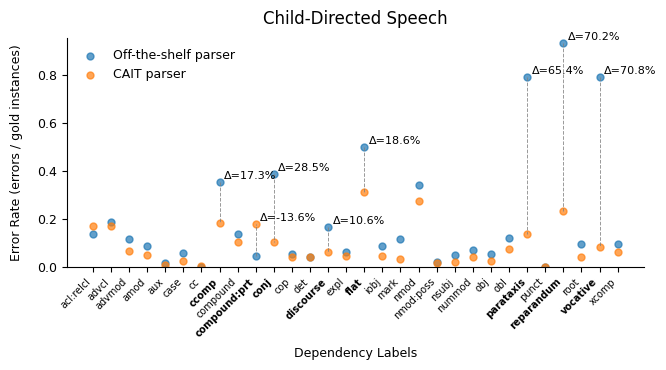

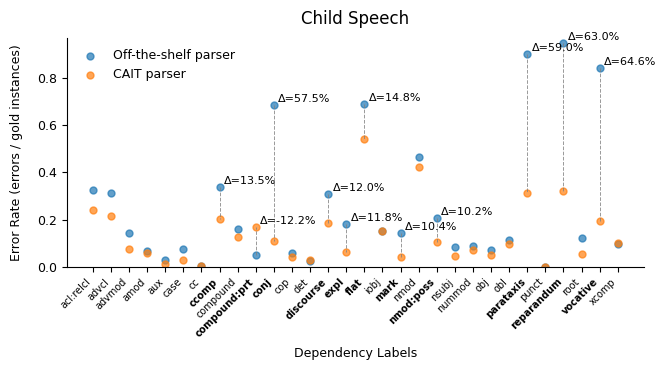

In [35]:
import matplotlib.pyplot as plt
import numpy as np

DELTA_THRESHOLD = 0.1

labels = sorted(labels_final)

# ── CDS ──────────────────────────────────────────────────────────────────────
y_off_cds = [
    off_the_shelf_adult.get(lbl, 0) / gold_counts_cds[lbl]
    if gold_counts_cds.get(lbl, 0) > 0 else 0
    for lbl in labels
]
y_supar_cds = [
    cds_supar_adult.get(lbl, 0) / gold_counts_cds[lbl]
    if gold_counts_cds.get(lbl, 0) > 0 else 0
    for lbl in labels
]

# ── CS ───────────────────────────────────────────────────────────────────────
y_off_cs = [
    off_the_shelf_child.get(lbl, 0) / gold_counts_cs[lbl]
    if gold_counts_cs.get(lbl, 0) > 0 else 0
    for lbl in labels
]
y_supar_cs = [
    cds_supar_child.get(lbl, 0) / gold_counts_cs[lbl]
    if gold_counts_cs.get(lbl, 0) > 0 else 0
    for lbl in labels
]

x = np.arange(len(labels))

def plot_error_rate(y_off, y_supar, title, filename):
    plt.figure(figsize=(6.8, 3.8), facecolor='white')
    ax = plt.gca()

    plt.scatter(x, y_off, alpha=0.7, s=25, label="Off-the-shelf parser")
    plt.scatter(x, y_supar, alpha=0.7, s=25, label="CAIT parser")

    for i, lbl in enumerate(labels):
        delta = y_off[i] - y_supar[i]
        if abs(delta) > DELTA_THRESHOLD:
            plt.plot(
                [i, i], [y_off[i], y_supar[i]],
                linestyle="--", linewidth=0.7, color="gray", alpha=0.8
            )
            y_pos = max(y_off[i], y_supar[i]) + 0.004
            plt.text(
                i + 0.25, y_pos, f"Δ={delta*100:.1f}%",
                ha="left", va="bottom", fontsize=8
            )

    plt.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')

    plt.xticks(x, labels, rotation=45, ha="right", fontsize=7)

    for i, lbl in enumerate(labels):
        delta = y_off[i] - y_supar[i]
        ax.get_xticklabels()[i].set_fontweight(
            'bold' if abs(delta) >= DELTA_THRESHOLD else 'normal'
        )

    plt.yticks(fontsize=9)
    plt.ylim(0, max(max(y_off), max(y_supar)) + 0.02)
    plt.ylabel("Error Rate (errors / gold instances)", fontsize=9, labelpad=10)
    plt.xlabel("Dependency Labels", fontsize=9, labelpad=6)
    plt.title(title, fontsize=12, pad=10)
    plt.legend(fontsize=9, frameon=False)
    plt.tight_layout()
    plt.savefig(filename, format="pdf", bbox_inches="tight")
    plt.show()

plot_error_rate(y_off_cds, y_supar_cds, "Child-Directed Speech", "comparison_error_rate_cds.pdf")
plot_error_rate(y_off_cs,  y_supar_cs,  "Child Speech",          "comparison_error_rate_cs.pdf")

## For OFF THE SHELF stanza 
The directions with more errors (>50) are the following:

1. obl:npmod -> iobj
2. parataxis -> nmod
3. nmod -> compound
4. nmod:poss -> compound
5. amod -> compound 
6. conj -> compound
7. nmod -> obl


## For SUPAR CDL 
The directions with more errors (>30) are the following:

1. flat -> conj
2. nmod -> compound
3. nmod -> obl
4. conj -> parataxis

### STANZA ROBERTA CDS



In [22]:
INPUT_FILE = Path(
    "./error_analysis/"
    "Stanza_Roberta_cds_errors.conllu"
)

OUTPUT_DIR = INPUT_FILE.parent / "fine_grained_errors_CDS_Roberta_Stanza"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [23]:
TOP_ERRORS = [
    ("advmod", "compound:prt"),
    ("obl:unmarked", "obl:tmod"),
    ("root", "nsubj"),
    ("det", "nmod:poss"),
    ("discourse", "det"),
    ("nmod", "obl"),
    ("conj", "flat"),
    ("root","parataxis"),
    ("nsubj", "root"),
    ("root", "conj"),
    ("nmod", "compound"),
    ("discourse", "root"),
    ("parataxis", "root"),
    ("reparandum", "root"),
    ("root", "advmod"),
]

# Prepare output files
out_files = {}
for g, p in TOP_ERRORS:
    fname = f"gold_{g}__pred_{p}.conllu"
    out_files[(g, p)] = open(OUTPUT_DIR / fname, "w", encoding="utf-8")

def flush_sentence(sentence_lines, sentence_errors):
    """
    Write sentence to all error-specific files it belongs to
    """
    for err in sentence_errors:
        out_files[err].write("".join(sentence_lines))
        out_files[err].write("\n")

with open(INPUT_FILE, encoding="utf-8") as f:
    sentence_lines = []
    sentence_errors = set()
    last_gold = None

    for line in f:
        if line.startswith("# sentence:"):
            # New sentence begins — flush previous
            if sentence_lines and sentence_errors:
                flush_sentence(sentence_lines, sentence_errors)

            sentence_lines = [line]
            sentence_errors = set()
            last_gold = None
            continue

        sentence_lines.append(line)

        # Capture Gold line
        if line.startswith("Gold: token="):
            gold_match = re.search(r"label=([^\s]+)", line)
            if gold_match:
                last_gold = gold_match.group(1)

        # Capture Pred line (must follow Gold)
        elif line.startswith("Pred: token=") and last_gold is not None:
            pred_match = re.search(r"label=([^\s]+)", line)
            if pred_match:
                pred_label = pred_match.group(1)

                for g, p in TOP_ERRORS:
                    if last_gold == g and pred_label == p:
                        sentence_errors.add((g, p))

            last_gold = None

    # Flush final sentence
    if sentence_lines and sentence_errors:
        flush_sentence(sentence_lines, sentence_errors)

# Close files
for f in out_files.values():
    f.close()

print(f"Fine-grained error files written to: {OUTPUT_DIR}")

Fine-grained error files written to: error_analysis/fine_grained_errors_CDS_Roberta_Stanza


### BIAFFINE ENGLISH

In [24]:
INPUT_FILE = Path(
    "./error_analysis/"
    "parser_predictions_Roberta_eng_biaffine_errors.conllu"
)

OUTPUT_DIR = INPUT_FILE.parent / "fine_grained_errors_ENG_Roberta"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [25]:
TOP_ERRORS = [
    ("nsubj", "root"),
    ("root", "nsubj"),
    ("conj", "discourse"),
    ("root", "discourse"),
    ("root", "compound"),
    ("mark", "advmod"),
    ("conj", "root"),
    ("parataxis","root"),
    ("advmod", "compound:prt"),
    ("discourse", "root"),
]

# Prepare output files
out_files = {}
for g, p in TOP_ERRORS:
    fname = f"gold_{g}__pred_{p}.conllu"
    out_files[(g, p)] = open(OUTPUT_DIR / fname, "w", encoding="utf-8")

def flush_sentence(sentence_lines, sentence_errors):
    """
    Write sentence to all error-specific files it belongs to
    """
    for err in sentence_errors:
        out_files[err].write("".join(sentence_lines))
        out_files[err].write("\n")

with open(INPUT_FILE, encoding="utf-8") as f:
    sentence_lines = []
    sentence_errors = set()
    last_gold = None

    for line in f:
        if line.startswith("# sentence:"):
            # New sentence begins — flush previous
            if sentence_lines and sentence_errors:
                flush_sentence(sentence_lines, sentence_errors)

            sentence_lines = [line]
            sentence_errors = set()
            last_gold = None
            continue

        sentence_lines.append(line)

        # Capture Gold line
        if line.startswith("Gold: token="):
            gold_match = re.search(r"label=([^\s]+)", line)
            if gold_match:
                last_gold = gold_match.group(1)

        # Capture Pred line (must follow Gold)
        elif line.startswith("Pred: token=") and last_gold is not None:
            pred_match = re.search(r"label=([^\s]+)", line)
            if pred_match:
                pred_label = pred_match.group(1)

                for g, p in TOP_ERRORS:
                    if last_gold == g and pred_label == p:
                        sentence_errors.add((g, p))

            last_gold = None

    # Flush final sentence
    if sentence_lines and sentence_errors:
        flush_sentence(sentence_lines, sentence_errors)

# Close files
for f in out_files.values():
    f.close()

print(f"Fine-grained error files written to: {OUTPUT_DIR}")

Fine-grained error files written to: error_analysis/fine_grained_errors_ENG_Roberta


### BIAFFINE CDS

In [26]:
INPUT_FILE = Path(
    "./error_analysis/"
    "parser_predictions_Roberta_CDS_biaffine_errors.conllu"
)

OUTPUT_DIR = INPUT_FILE.parent / "fine_grained_errors_CDS_Roberta"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [27]:
TOP_ERRORS = [
    ("root", "nsubj"),
    ("det", "nmod:possd"),
    ("advmod", "compound:prt"),
    ("nsubj", "root"),
    ("nmod", "compound"),
    ("compound:prt", "advmod"),
    ("root","advmod"),
    ("parataxis", "root"),
    ("discourse", "root"),
    ("root", "parataxis"),
]


# Prepare output files
out_files = {}
for g, p in TOP_ERRORS:
    fname = f"gold_{g}__pred_{p}.conllu"
    out_files[(g, p)] = open(OUTPUT_DIR / fname, "w", encoding="utf-8")

def flush_sentence(sentence_lines, sentence_errors):
    """
    Write sentence to all error-specific files it belongs to
    """
    for err in sentence_errors:
        out_files[err].write("".join(sentence_lines))
        out_files[err].write("\n")

with open(INPUT_FILE, encoding="utf-8") as f:
    sentence_lines = []
    sentence_errors = set()
    last_gold = None

    for line in f:
        if line.startswith("# sentence:"):
            # New sentence begins — flush previous
            if sentence_lines and sentence_errors:
                flush_sentence(sentence_lines, sentence_errors)

            sentence_lines = [line]
            sentence_errors = set()
            last_gold = None
            continue

        sentence_lines.append(line)

        # Capture Gold line
        if line.startswith("Gold: token="):
            gold_match = re.search(r"label=([^\s]+)", line)
            if gold_match:
                last_gold = gold_match.group(1)

        # Capture Pred line (must follow Gold)
        elif line.startswith("Pred: token=") and last_gold is not None:
            pred_match = re.search(r"label=([^\s]+)", line)
            if pred_match:
                pred_label = pred_match.group(1)

                for g, p in TOP_ERRORS:
                    if last_gold == g and pred_label == p:
                        sentence_errors.add((g, p))

            last_gold = None

    # Flush final sentence
    if sentence_lines and sentence_errors:
        flush_sentence(sentence_lines, sentence_errors)

# Close files
for f in out_files.values():
    f.close()

print(f"Fine-grained error files written to: {OUTPUT_DIR}")

Fine-grained error files written to: error_analysis/fine_grained_errors_CDS_Roberta


### English OFF THE SHELF STANZA

In [28]:
INPUT_FILE = Path(
    "./error_analysis/"
    "parser_predictions_Stanza_off_the_shelf_old_errors.conllu"
)

OUTPUT_DIR = INPUT_FILE.parent / "fine_grained_errors_ENG_off_the_shelf"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [29]:
TOP_ERRORS = [
    ("conj", "root"),
    ("root", "discourse"),
    ("advmod", "compound:prt"),
    ("root", "nsubj"),
    ("root", "compound"),
    ("nsubj", "root"),
    ("parataxis","ccomp"),
    ("discourse", "det"),
    ("discourse", "root"),
    ("parataxisro", "root"),
]

# Prepare output files
out_files = {}
for g, p in TOP_ERRORS:
    fname = f"gold_{g}__pred_{p}.conllu"
    out_files[(g, p)] = open(OUTPUT_DIR / fname, "w", encoding="utf-8")

def flush_sentence(sentence_lines, sentence_errors):
    """
    Write sentence to all error-specific files it belongs to
    """
    for err in sentence_errors:
        out_files[err].write("".join(sentence_lines))
        out_files[err].write("\n")

with open(INPUT_FILE, encoding="utf-8") as f:
    sentence_lines = []
    sentence_errors = set()
    last_gold = None

    for line in f:
        if line.startswith("# sentence:"):
            # New sentence begins — flush previous
            if sentence_lines and sentence_errors:
                flush_sentence(sentence_lines, sentence_errors)

            sentence_lines = [line]
            sentence_errors = set()
            last_gold = None
            continue

        sentence_lines.append(line)

        # Capture Gold line
        if line.startswith("Gold: token="):
            gold_match = re.search(r"label=([^\s]+)", line)
            if gold_match:
                last_gold = gold_match.group(1)

        # Capture Pred line (must follow Gold)
        elif line.startswith("Pred: token=") and last_gold is not None:
            pred_match = re.search(r"label=([^\s]+)", line)
            if pred_match:
                pred_label = pred_match.group(1)

                for g, p in TOP_ERRORS:
                    if last_gold == g and pred_label == p:
                        sentence_errors.add((g, p))

            last_gold = None

    # Flush final sentence
    if sentence_lines and sentence_errors:
        flush_sentence(sentence_lines, sentence_errors)

# Close files
for f in out_files.values():
    f.close()

print(f"Fine-grained error files written to: {OUTPUT_DIR}")

Fine-grained error files written to: error_analysis/fine_grained_errors_ENG_off_the_shelf
